# Freenow case study

## Task description 

You are tasked with helping the Supply Product team to better understand user interaction,
metrics and engagement of FREENOW drivers:
Using the data from Freenow_drivers and Freenow_drivers_activity files, please answer:
1. What key metric(s) would you propose to monitor over time to measure the success of
the team's efforts in improving Drivers engagement and why? Clearly define your
metric(s) and present calculations showing trends or patterns as you see appropriate.
2. Can you help us identify which factors are associated with better engagement? What
segments are doing well and what could be improved? Can you propose any
recommendations (business initiatives or product changes) that could address these
opportunities?

## Expected Output

Summarise your findings, insights and recommendations in response to the questions above in a
presentation containing maximum 10 slides, this will be used later in the process by you in a
session with the data team/stakeholders. We expect that this is structured as you would do it on
a day to day, in order to present your findings/analysis to stakeholders.
Include an organized appendix sharing the details of your analysis that would be useful for the
team to understand your work, this should include the code used. You can use
SQL/Python/Jupyter Notebooks in order to explore the provided datasets. It's not allowed to use
GPT tools to generate code, slides, or to explore the datasets.

## Datasets description 

**Data**
A sample of data is provided in three separate .csv files:
1. Freenow_drivers.csv
2. Freenow_drivers_activity.csv
3. Freenow_drivers_campaign.csv

----------------------------------

1. *Freenow_drivers*

A user table with data on FREE NOW drivers including:
- Id_driver: the driver ID
- Date_registration: the date when the user was activated in FREE NOW
- Driver_rating: the average rating of the driver last 100 rides
- Gold_level_count: amount of times the driver reached gold status meaning they were
among the top performers in a specific week
- Receive_marketing: Takes one of two values, True if the driver accepted to receive
marketing and campaign communications and False, if not
- Country_code: Country where the user operates
- Service_type: If the user is TAXI or a Private Hire Vehicle (PHV)

2. *Freenow_drivers_activity*

A summary of the user activity including:
- Id_driver: the driver ID
- Active_date: date when the user operated in the platform
- Offers: number of requests for a ride that a driver received
- Bookings: number of requests accepted by the driver
- Bookings_cancelled_by_passenger: number of requests accepted by the driver and then
cancelled by the passenger, before the ride was completed
- Bookings_cancelled_by_driver: number of requests accepted by the driver and then
cancelled by the driver, before the ride was completed
- Rides: number of rides completed by the driver

3. *Freenow_drivers_campaign*

A summary of the campaign data including:
- Driver: the driver identification number in the test (different from previous id_driver, don't
try to join it)
- Rides_within_week: number of rides completed within one week after the update
- Test_group: Group that the driver was inserted in the email campaign.

## Data preparation 

In [1]:
# import sys
# packages = [
#     "pandas",      
#     "numpy",       
#     "matplotlib",  
#     "seaborn",     
#     "scikit-learn",
#     "scipy", 
#     "datetime"
# ]

# print("Starting simplified package installation...")

# for package in packages:
#     print(f"\nAttempting to install {package}...")
#     !{sys.executable} -m pip install {package}

In [2]:
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib as mpl
import seaborn as sns
import warnings
import numpy as np
from datetime import date
from scipy import stats
warnings.filterwarnings("ignore")

In [3]:
Freenow_drivers = pd.read_csv('/Users/romandius/Python Works/Data Files/freenow_drivers.csv')

In [4]:
Freenow_drivers.head()

,id_driver,date_registration,driver_rating,gold_level_count,receive_marketing,country_code,service_type
0,15260831,2015-11-18,4.85,2.0,True,ES,TAXI
1,58194598,2020-03-12,4.79,26.0,True,DE,PHV
2,21139412,2017-05-15,4.76,10.0,True,DE,TAXI
3,48382094,2019-03-20,4.91,3.0,False,DE,TAXI
4,52914047,2019-08-02,4.96,10.0,True,DE,PHV


In [5]:
Freenow_drivers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36972 entries, 0 to 36971
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_driver          36972 non-null  int64  
 1   date_registration  36972 non-null  object 
 2   driver_rating      36874 non-null  float64
 3   gold_level_count   34024 non-null  float64
 4   receive_marketing  36972 non-null  bool   
 5   country_code       36972 non-null  object 
 6   service_type       36972 non-null  object 
dtypes: bool(1), float64(2), int64(1), object(3)
memory usage: 1.7+ MB


In [6]:
Freenow_drivers.nunique()

id_driver            36771
date_registration     2492
driver_rating          122
gold_level_count       183
receive_marketing        2
country_code             2
service_type             2
dtype: int64

In [7]:
print(Freenow_drivers.date_registration.max(), ' Max date')
print(Freenow_drivers.date_registration.min(), ' Min date')

2020-06-27  Max date
2011-05-29  Min date


Time range is pretty huge, but registrations split relatively equily

In [8]:
print(Freenow_drivers[Freenow_drivers.duplicated()])

Empty DataFrame
Columns: [id_driver, date_registration, driver_rating, gold_level_count, receive_marketing, country_code, service_type]
Index: []


We have some blankes in driver rating, gold_level_count, date_registration format should be changed,  gold_level_count i would change to int type, as it shows frequency, Na values in it can be replaced with 0 if needed. We also have some duplicates in id_driver column, should be checked. So tehre are no row duplicates and it is just same driver_id

In [9]:
Freenow_drivers['date_registration'] = pd.to_datetime(Freenow_drivers['date_registration'])
Freenow_drivers['gold_level_count'] = Freenow_drivers['gold_level_count'].astype('Int64')
Freenow_drivers['gold_level_count'] = Freenow_drivers['gold_level_count'].fillna(0)

In [10]:
Freenow_drivers.groupby(Freenow_drivers['date_registration'].dt.to_period('Y')).agg({'id_driver': 'nunique'})

,id_driver
date_registration,
2011,1708
2012,2122
2013,2564
2014,1585
2015,3244
2016,4011
2017,4057
2018,5614
2019,8165


In [11]:
Freenow_drivers.country_code.unique()

array(['ES', 'DE'], dtype=object)

In [12]:
Freenow_drivers.country_code.value_counts()

country_code
DE    25802
ES    11170
Name: count, dtype: int64

In [13]:
Freenow_drivers.loc[Freenow_drivers['driver_rating'].isna()]

,id_driver,date_registration,driver_rating,gold_level_count,receive_marketing,country_code,service_type
518,55031827,2019-10-31,NaN,0,False,DE,TAXI
1024,58697588,2020-06-03,NaN,0,True,ES,TAXI
1025,53800466,2019-09-11,NaN,0,False,DE,TAXI
1333,58688930,2020-06-02,NaN,0,True,DE,TAXI
1793,57940823,2020-03-02,NaN,0,True,DE,PHV
...,...,...,...,...,...,...,...
35428,57817330,2020-02-27,NaN,0,False,ES,TAXI
35864,56877222,2020-01-16,NaN,0,False,DE,TAXI
35886,53777862,2019-09-10,NaN,0,False,DE,TAXI
36386,58645027,2020-05-28,NaN,0,True,DE,TAXI


Given it is only 98 drivers with no rating out of 37k, we can easily delete them 

In [14]:
grouped = Freenow_drivers.groupby('id_driver').agg({'date_registration': 'count'}).sort_values(by = 'date_registration', ascending=False).reset_index()
multy_id = grouped.id_driver.loc[grouped.date_registration > 1]

In [15]:
Freenow_drivers.loc[Freenow_drivers.id_driver.isin(multy_id)].sort_values(by = 'id_driver')

,id_driver,date_registration,driver_rating,gold_level_count,receive_marketing,country_code,service_type
11859,1343,2011-05-29,4.90,1,True,DE,TAXI
29806,1343,2011-05-29,4.90,1,True,DE,PHV
19773,1541,2011-05-29,4.74,5,True,DE,PHV
24852,1541,2011-05-29,4.74,5,True,DE,TAXI
17324,1770,2011-05-29,5.00,12,True,DE,TAXI
...,...,...,...,...,...,...,...
24050,57269427,2020-02-03,4.94,0,True,DE,TAXI
8793,57601808,2020-02-18,4.85,0,True,DE,PHV
36952,57601808,2020-02-18,4.85,0,True,DE,TAXI
14774,58350526,2020-03-31,4.88,4,True,DE,PHV


In [16]:
Freenow_drivers['both_service_type'] = Freenow_drivers['id_driver'].isin(multy_id)

So these are no directly duplicates, but rather participation in both private hire and regular taxi axtivities. So i suggest splitting dataset into 2 parts: one for regular taxi and another one for private.

In [17]:
drivers_taxi =  Freenow_drivers.loc[Freenow_drivers.service_type == "TAXI"]
drivers_private =  Freenow_drivers.loc[Freenow_drivers.service_type == "PHV"]

In [18]:
drivers_taxi.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31321 entries, 0 to 36971
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   id_driver          31321 non-null  int64         
 1   date_registration  31321 non-null  datetime64[ns]
 2   driver_rating      31260 non-null  float64       
 3   gold_level_count   31321 non-null  Int64         
 4   receive_marketing  31321 non-null  bool          
 5   country_code       31321 non-null  object        
 6   service_type       31321 non-null  object        
 7   both_service_type  31321 non-null  bool          
dtypes: Int64(1), bool(2), datetime64[ns](1), float64(1), int64(1), object(2)
memory usage: 1.8+ MB


In [19]:
drivers_taxi.nunique()

id_driver            31321
date_registration     2481
driver_rating          122
gold_level_count       183
receive_marketing        2
country_code             2
service_type             1
both_service_type        2
dtype: int64

In [20]:
drivers_private.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5651 entries, 1 to 36970
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   id_driver          5651 non-null   int64         
 1   date_registration  5651 non-null   datetime64[ns]
 2   driver_rating      5614 non-null   float64       
 3   gold_level_count   5651 non-null   Int64         
 4   receive_marketing  5651 non-null   bool          
 5   country_code       5651 non-null   object        
 6   service_type       5651 non-null   object        
 7   both_service_type  5651 non-null   bool          
dtypes: Int64(1), bool(2), datetime64[ns](1), float64(1), int64(1), object(2)
memory usage: 325.6+ KB


In [21]:
drivers_private.nunique()

id_driver            5651
date_registration     448
driver_rating          66
gold_level_count       66
receive_marketing       2
country_code            1
service_type            1
both_service_type       2
dtype: int64

Now it looks much more organised

In [22]:
Freenow_drivers_activity = pd.read_csv('/Users/romandius/Python Works/Data Files/freenow_drivers_activity.csv')

In [23]:
Freenow_drivers_activity.isna().sum()

id_driver                          0
active_date                        0
offers                             0
bookings                           0
bookings_cancelled_by_passenger    0
bookings_cancelled_by_driver       0
rides                              0
dtype: int64

I am not sure, but number of accepted requests should be smaller than number of offers, i would eliminate those

In [24]:
errors = Freenow_drivers_activity.loc[Freenow_drivers_activity.offers < Freenow_drivers_activity.bookings]

thats about 35k rows with higher number of bookings than orders or 2% of whole dataset, which is relatively a lot, but because i dont know how to properly treat it, i delete it

In [25]:
Freenow_drivers_activity = Freenow_drivers_activity[~(Freenow_drivers_activity.offers < Freenow_drivers_activity.bookings)]

In [26]:
Freenow_drivers_activity.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1792682 entries, 0 to 1828411
Data columns (total 7 columns):
 #   Column                           Dtype 
---  ------                           ----- 
 0   id_driver                        int64 
 1   active_date                      object
 2   offers                           int64 
 3   bookings                         int64 
 4   bookings_cancelled_by_passenger  int64 
 5   bookings_cancelled_by_driver     int64 
 6   rides                            int64 
dtypes: int64(6), object(1)
memory usage: 109.4+ MB


In [27]:
Freenow_drivers_activity['active_date'] = pd.to_datetime(Freenow_drivers_activity['active_date'])

In [28]:
Freenow_drivers_activity.duplicated().sum()

np.int64(0)

In [29]:
Freenow_drivers_activity.groupby(Freenow_drivers_activity['active_date'].dt.to_period('Y')).agg({'id_driver': 'nunique'})

,id_driver
active_date,
2020,36754


No Duplicates, that is good, otherwise it would really hard to check all minor limitations that might exist in the dataset, so i would suggest proceed with analysis. We have 36754 ids in activity table and data only for the 2020 year. That might be an interesting case for comparing drivers registered in different years and how it effects the perception 

In [30]:
Freenow_drivers_campaign = pd.read_csv('/Users/romandius/Python Works/Data Files/freenow_driver_campaign.csv', skiprows=1)

In [31]:
Freenow_drivers_campaign.head()

,driver,rides_within_week,test_group
0,1,88,A
1,2,56,B
2,3,80,B
3,4,49,A
4,5,61,A


In [32]:
merged_data = pd.merge(Freenow_drivers_activity, Freenow_drivers, how="left", on=["id_driver", "id_driver"])

In [33]:
merged_data.shape

(1804755, 14)

In [34]:
merged_data.country_code.value_counts()

country_code
DE    1268787
ES     535968
Name: count, dtype: int64

## Analysis

Lets start analysing table *Freenow_drivers_activity*

what KPIs can we retrieve from it: 

- CR rides/offers
- booking/offers
- bookings_cancelled_by_driver/offers
- bookings_cancelled_by_passenger/offers

For us the goal is to complete a ride, this brings money to company. All of mentioned above metrics we can calculate per driver or understand totals. 

To understand the engagement of drivers, we can look at 3 things:

1. how rating affects their willingness to take an offer / how rating affects cancellation rate (from both sides) / does rating affect amount of offers?
2. how gold level count affects the same? do drivers with higher count of perfomance achivements keep the same level? 
3. how promotion does the same? 

Lets start from the basics and calculate MAD and WAU 

In [35]:
MAD = Freenow_drivers_activity.groupby(Freenow_drivers_activity['active_date'].dt.to_period('M')).agg({'id_driver': 'nunique'}).reset_index()

In [36]:
MAD.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype    
---  ------       --------------  -----    
 0   active_date  6 non-null      period[M]
 1   id_driver    6 non-null      int64    
dtypes: int64(1), period[M](1)
memory usage: 228.0 bytes


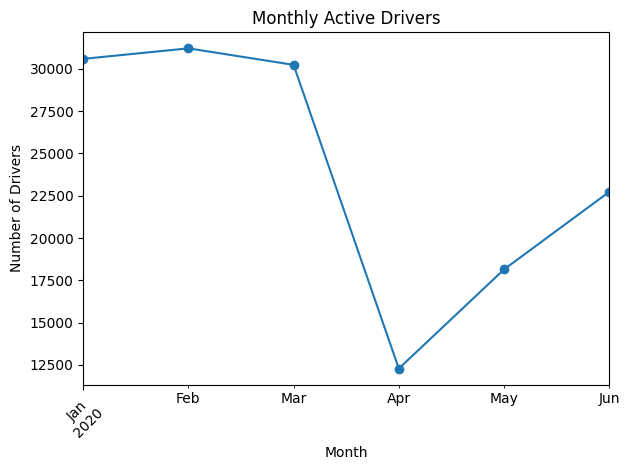

In [37]:
MAD.set_index('active_date').plot(marker='o', legend=False)
plt.title('Monthly Active Drivers')
plt.xlabel("Month")
plt.ylabel("Number of Drivers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

We have a significant drop off in numbers in April, might be worrying

In [38]:
WAD = Freenow_drivers_activity.groupby(Freenow_drivers_activity['active_date'].dt.strftime('%Y-%U')).agg({'id_driver': 'nunique'}).reset_index()

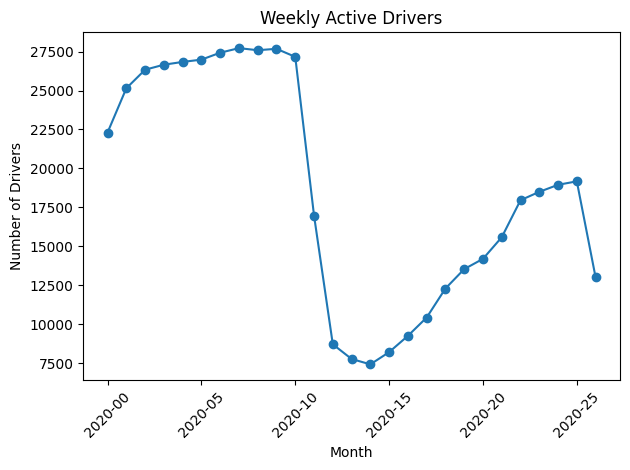

In [39]:
WAD.set_index('active_date').plot(marker='o', legend=False)
plt.title('Weekly Active Drivers')
plt.xlabel("Month")
plt.ylabel("Number of Drivers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Particularly we can observe dropp off after 10th week and then it slowly recovers until second drop of arounf 25th week. Though, high demand for rides might be explained by winter holydays and in general worse wether during the winter. Right now for us it should much more interesting to compare relative metrics, that i came up with a little before

In [40]:
grouped_data = Freenow_drivers_activity.groupby(Freenow_drivers_activity['active_date']).agg({'id_driver': 'nunique', 'offers': 'sum', 'bookings': 'sum', 'bookings_cancelled_by_passenger':'sum', 'bookings_cancelled_by_driver':'sum', 'rides':'sum'}).reset_index()

In [41]:
grouped_data

,active_date,id_driver,offers,bookings,bookings_cancelled_by_passenger,bookings_cancelled_by_driver,rides
0,2020-01-01,13939,1676982,101532,13596,22396,66109
1,2020-01-02,11926,190602,38928,4121,2965,31876
2,2020-01-03,13313,127378,45328,4802,3315,37254
3,2020-01-04,11982,173679,46441,5182,4055,37264
4,2020-01-05,11202,187785,43785,5353,4188,34308
...,...,...,...,...,...,...,...
177,2020-06-26,10868,77875,32990,3612,1857,27561
178,2020-06-27,9559,96043,35182,4273,3029,27951
179,2020-06-28,7800,62236,25225,3041,2397,19835
180,2020-06-29,9505,52789,25142,2651,1478,21038


In order to understand engagement of drivers, i would try to understand the average numbers by date in every category

In [42]:
relative_data = pd.DataFrame({
    'active_date': grouped_data['active_date'],
    'avg_offers_CR_ride': grouped_data['rides'] / grouped_data['offers'],
    'avg_accept_offer_rate': grouped_data['bookings'] / grouped_data['offers'],
    'avg_cancelled_by_driver_rate': grouped_data['bookings_cancelled_by_driver'] / grouped_data['offers'],
    'avg_cancelled_by_passenger_rate': grouped_data['bookings_cancelled_by_passenger'] / grouped_data['offers'], 
    'avg_offers_per_driver': grouped_data['offers'] / grouped_data['id_driver'],
    'avg_rides_per_driver': grouped_data['rides'] / grouped_data['id_driver'],
    'avg_cancelled_by_customer_per_driver': grouped_data['bookings_cancelled_by_passenger'] / grouped_data['id_driver'],
    'avg_cancelled_by_driver_per_driver': grouped_data['bookings_cancelled_by_driver'] / grouped_data['id_driver']
})

relative_data = relative_data.round(2)

In [43]:
relative_data

,active_date,avg_offers_CR_ride,avg_accept_offer_rate,avg_cancelled_by_driver_rate,avg_cancelled_by_passenger_rate,avg_offers_per_driver,avg_rides_per_driver,avg_cancelled_by_customer_per_driver,avg_cancelled_by_driver_per_driver
0,2020-01-01,0.04,0.06,0.01,0.01,120.31,4.74,0.98,1.61
1,2020-01-02,0.17,0.20,0.02,0.02,15.98,2.67,0.35,0.25
2,2020-01-03,0.29,0.36,0.03,0.04,9.57,2.80,0.36,0.25
3,2020-01-04,0.21,0.27,0.02,0.03,14.49,3.11,0.43,0.34
4,2020-01-05,0.18,0.23,0.02,0.03,16.76,3.06,0.48,0.37
...,...,...,...,...,...,...,...,...,...
177,2020-06-26,0.35,0.42,0.02,0.05,7.17,2.54,0.33,0.17
178,2020-06-27,0.29,0.37,0.03,0.04,10.05,2.92,0.45,0.32
179,2020-06-28,0.32,0.41,0.04,0.05,7.98,2.54,0.39,0.31
180,2020-06-29,0.40,0.48,0.03,0.05,5.55,2.21,0.28,0.16


Now we have for each date average numbers, and now we can compare them to the actuals for every driver in the table

In [44]:
Freenow_drivers_activity.head()

,id_driver,active_date,offers,bookings,bookings_cancelled_by_passenger,bookings_cancelled_by_driver,rides
0,3,2020-01-01,65,18,3,4,11
1,3,2020-01-02,3,2,0,1,1
2,3,2020-01-03,1,1,0,0,1
4,3,2020-01-05,6,4,0,1,3
5,3,2020-01-06,3,2,0,0,2


In [45]:
metrics = pd.DataFrame({
    'id_driver': Freenow_drivers_activity.id_driver, 
    'active_date': Freenow_drivers_activity.active_date,
    'offers': Freenow_drivers_activity.offers, 
    'bookings': Freenow_drivers_activity.bookings, 
    'bookings_cancelled_by_passenger': Freenow_drivers_activity.bookings_cancelled_by_passenger,
    'bookings_cancelled_by_driver': Freenow_drivers_activity.bookings_cancelled_by_driver,
    'rides': Freenow_drivers_activity.rides,
    'offers_CR_ride': Freenow_drivers_activity['rides'] / Freenow_drivers_activity['offers'],
    'accept_offer_rate': Freenow_drivers_activity['bookings'] / Freenow_drivers_activity['offers'],
    'cancelled_by_driver_rate': Freenow_drivers_activity['bookings_cancelled_by_driver'] / Freenow_drivers_activity['offers'],
    'cancelled_by_passenger_rate': Freenow_drivers_activity['bookings_cancelled_by_passenger'] / Freenow_drivers_activity['offers']
})

metrics = metrics.round(2)

In [46]:
metrics

,id_driver,active_date,offers,bookings,bookings_cancelled_by_passenger,bookings_cancelled_by_driver,rides,offers_CR_ride,accept_offer_rate,cancelled_by_driver_rate,cancelled_by_passenger_rate
0,3,2020-01-01,65,18,3,4,11,0.17,0.28,0.06,0.05
1,3,2020-01-02,3,2,0,1,1,0.33,0.67,0.33,0.00
2,3,2020-01-03,1,1,0,0,1,1.00,1.00,0.00,0.00
4,3,2020-01-05,6,4,0,1,3,0.50,0.67,0.17,0.00
5,3,2020-01-06,3,2,0,0,2,0.67,0.67,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...
1828406,58981568,2020-06-29,2,2,1,0,1,0.50,1.00,0.00,0.50
1828407,58996344,2020-06-27,4,2,0,0,2,0.50,0.50,0.00,0.00
1828409,58996344,2020-06-29,7,3,2,0,1,0.14,0.43,0.00,0.29
1828410,58996817,2020-06-27,16,5,1,0,4,0.25,0.31,0.00,0.06


In [47]:
result = pd.merge(metrics, relative_data, how="left", on=["active_date", "active_date"])

In [48]:
kpis = [
    ("offers_CR_ride", "avg_offers_CR_ride"),
    ("accept_offer_rate", "avg_accept_offer_rate"),
    ("cancelled_by_driver_rate", "avg_cancelled_by_driver_rate"),
    ("cancelled_by_passenger_rate", "avg_cancelled_by_passenger_rate"),
    ("offers", "avg_offers_per_driver"),
    ("rides", "avg_rides_per_driver"),
    ("bookings_cancelled_by_passenger", "avg_cancelled_by_customer_per_driver"),
    ("bookings_cancelled_by_driver", "avg_cancelled_by_driver_per_driver")
]

for kpis, avg_metric in kpis:
    diff_col = f"{kpis}_diff"
    result[diff_col] = result[kpis] - result[avg_metric]

In [49]:
ordered_columns = [
    "id_driver",
    "active_date"
]

metric_groups = {
    "offers": "avg_offers_per_driver",
    "rides": "avg_rides_per_driver",
    "bookings_cancelled_by_passenger": "avg_cancelled_by_customer_per_driver",
    "bookings_cancelled_by_driver": "avg_cancelled_by_driver_per_driver",
    "offers_CR_ride": "avg_offers_CR_ride",
    "accept_offer_rate": "avg_accept_offer_rate",
    "cancelled_by_driver_rate": "avg_cancelled_by_driver_rate",
    "cancelled_by_passenger_rate": "avg_cancelled_by_passenger_rate"
}

for base, avg in metric_groups.items():
    diff = f"{base}_diff"
    label_col = f"{base}_level"
    
    q25 = result[diff].quantile(0.25)
    q75 = result[diff].quantile(0.75)

    result[label_col] = result[diff].apply(
        lambda x: "above average" if x > q75 else
                  "below average" if x < q25 else
                  "almost average"
    )

    ordered_columns.extend([base, avg, diff, label_col])

result = result[ordered_columns]

In [50]:
result

,id_driver,active_date,offers,avg_offers_per_driver,offers_diff,offers_level,rides,avg_rides_per_driver,rides_diff,rides_level,...,accept_offer_rate_diff,accept_offer_rate_level,cancelled_by_driver_rate,avg_cancelled_by_driver_rate,cancelled_by_driver_rate_diff,cancelled_by_driver_rate_level,cancelled_by_passenger_rate,avg_cancelled_by_passenger_rate,cancelled_by_passenger_rate_diff,cancelled_by_passenger_rate_level
0,3,2020-01-01,65,120.31,-55.31,below average,11,4.74,6.26,above average,...,0.22,almost average,0.06,0.01,0.05,above average,0.05,0.01,0.04,above average
1,3,2020-01-02,3,15.98,-12.98,below average,1,2.67,-1.67,almost average,...,0.47,above average,0.33,0.02,0.31,above average,0.00,0.02,-0.02,almost average
2,3,2020-01-03,1,9.57,-8.57,almost average,1,2.80,-1.80,almost average,...,0.64,above average,0.00,0.03,-0.03,below average,0.00,0.04,-0.04,almost average
3,3,2020-01-05,6,16.76,-10.76,below average,3,3.06,-0.06,almost average,...,0.44,above average,0.17,0.02,0.15,above average,0.00,0.03,-0.03,almost average
4,3,2020-01-06,3,23.42,-20.42,below average,2,2.95,-0.95,almost average,...,0.51,above average,0.00,0.01,-0.01,above average,0.00,0.02,-0.02,almost average
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1792677,58981568,2020-06-29,2,5.55,-3.55,almost average,1,2.21,-1.21,almost average,...,0.52,above average,0.00,0.03,-0.03,below average,0.50,0.05,0.45,above average
1792678,58996344,2020-06-27,4,10.05,-6.05,almost average,2,2.92,-0.92,almost average,...,0.13,almost average,0.00,0.03,-0.03,below average,0.00,0.04,-0.04,almost average
1792679,58996344,2020-06-29,7,5.55,1.45,almost average,1,2.21,-1.21,almost average,...,-0.05,almost average,0.00,0.03,-0.03,below average,0.29,0.05,0.24,above average
1792680,58996817,2020-06-27,16,10.05,5.95,above average,4,2.92,1.08,above average,...,-0.06,almost average,0.00,0.03,-0.03,below average,0.06,0.04,0.02,above average


Now, once the table with all kpis is finished, i can merge first table to get some info about drivers, but we need to do it separately, because we have two types of taxy riding 

In [51]:
final_table_taxi = pd.merge(result, drivers_taxi, how="left", on=["id_driver", "id_driver"])
final_table_private = pd.merge(result, drivers_private, how="left", on=["id_driver", "id_driver"])

In [52]:
final_table_taxi.isna().sum()

id_driver                                     0
active_date                                   0
offers                                        0
avg_offers_per_driver                         0
offers_diff                                   0
offers_level                                  0
rides                                         0
avg_rides_per_driver                          0
rides_diff                                    0
rides_level                                   0
bookings_cancelled_by_passenger               0
avg_cancelled_by_customer_per_driver          0
bookings_cancelled_by_passenger_diff          0
bookings_cancelled_by_passenger_level         0
bookings_cancelled_by_driver                  0
avg_cancelled_by_driver_per_driver            0
bookings_cancelled_by_driver_diff             0
bookings_cancelled_by_driver_level            0
offers_CR_ride                                0
avg_offers_CR_ride                            0
offers_CR_ride_diff                     

In [53]:
final_table_private.isna().sum()

id_driver                                      0
active_date                                    0
offers                                         0
avg_offers_per_driver                          0
offers_diff                                    0
offers_level                                   0
rides                                          0
avg_rides_per_driver                           0
rides_diff                                     0
rides_level                                    0
bookings_cancelled_by_passenger                0
avg_cancelled_by_customer_per_driver           0
bookings_cancelled_by_passenger_diff           0
bookings_cancelled_by_passenger_level          0
bookings_cancelled_by_driver                   0
avg_cancelled_by_driver_per_driver             0
bookings_cancelled_by_driver_diff              0
bookings_cancelled_by_driver_level             0
offers_CR_ride                                 0
avg_offers_CR_ride                             0
offers_CR_ride_diff 

So they are excluding each other and we can drop those Na rows 

In [54]:
final_table_taxi = final_table_taxi.dropna()
final_table_private = final_table_private.dropna()

In [55]:
final_table_taxi.shape

(1527512, 41)

In [56]:
final_table_private.shape

(277086, 41)

In [57]:
final_table_taxi['diff_days'] = (final_table_taxi['active_date'] - final_table_taxi['date_registration']).dt.days
final_table_taxi['diff_years'] = final_table_taxi['diff_days'] / 365.25
final_table_private['diff_days'] = (final_table_private['active_date'] - final_table_private['date_registration']).dt.days
final_table_private['diff_years'] = final_table_private['diff_days'] / 365.25

In [58]:
final_table_private['diff_years']=final_table_private['diff_years'].round(0)
final_table_taxi['diff_years']=final_table_taxi['diff_years'].round(0)

In [59]:
final_table_taxi.head()

,id_driver,active_date,offers,avg_offers_per_driver,offers_diff,offers_level,rides,avg_rides_per_driver,rides_diff,rides_level,...,cancelled_by_passenger_rate_level,date_registration,driver_rating,gold_level_count,receive_marketing,country_code,service_type,both_service_type,diff_days,diff_years
0,3,2020-01-01,65,120.31,-55.31,below average,11,4.74,6.26,above average,...,above average,2011-05-29,4.87,22,True,DE,TAXI,False,3139,9.0
1,3,2020-01-02,3,15.98,-12.98,below average,1,2.67,-1.67,almost average,...,almost average,2011-05-29,4.87,22,True,DE,TAXI,False,3140,9.0
2,3,2020-01-03,1,9.57,-8.57,almost average,1,2.80,-1.80,almost average,...,almost average,2011-05-29,4.87,22,True,DE,TAXI,False,3141,9.0
3,3,2020-01-05,6,16.76,-10.76,below average,3,3.06,-0.06,almost average,...,almost average,2011-05-29,4.87,22,True,DE,TAXI,False,3143,9.0
4,3,2020-01-06,3,23.42,-20.42,below average,2,2.95,-0.95,almost average,...,almost average,2011-05-29,4.87,22,True,DE,TAXI,False,3144,9.0


In [60]:
level_columns = [col for col in final_table_taxi.columns if col.endswith('_level')]
last_8_columns = final_table_taxi.columns[-8:].tolist()
selected_columns = ['id_driver', 'active_date'] + level_columns + last_8_columns
final_table_taxi_filtered = final_table_taxi[selected_columns]
level_columns = [col for col in final_table_private.columns if col.endswith('_level')]
last_8_columns = final_table_private.columns[-8:].tolist()
selected_columns = ['id_driver', 'active_date'] + level_columns + last_8_columns
final_table_private_filtered = final_table_private[selected_columns]

In [61]:
final_table_private_filtered

,id_driver,active_date,offers_level,rides_level,bookings_cancelled_by_passenger_level,bookings_cancelled_by_driver_level,offers_CR_ride_level,accept_offer_rate_level,cancelled_by_driver_rate_level,cancelled_by_passenger_rate_level,driver_rating,gold_level_count,receive_marketing,country_code,service_type,both_service_type,diff_days,diff_years
16280,1073,2020-01-12,below average,above average,below average,below average,above average,almost average,almost average,almost average,4.77,0,True,DE,PHV,False,3150,9.0
16281,1073,2020-02-16,below average,almost average,below average,below average,above average,above average,almost average,almost average,4.77,0,True,DE,PHV,False,3185,9.0
20373,1343,2020-03-20,almost average,almost average,almost average,almost average,above average,above average,below average,below average,4.90,1,True,DE,PHV,True,3218,9.0
20374,1343,2020-03-21,almost average,almost average,above average,almost average,almost average,almost average,below average,above average,4.90,1,True,DE,PHV,True,3219,9.0
20375,1343,2020-03-25,almost average,almost average,almost average,almost average,above average,above average,below average,below average,4.90,1,True,DE,PHV,True,3223,9.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1792677,58981568,2020-06-29,almost average,almost average,above average,almost average,almost average,above average,below average,above average,4.83,0,True,DE,PHV,False,3,0.0
1792678,58996344,2020-06-27,almost average,almost average,below average,almost average,almost average,almost average,below average,almost average,4.89,0,True,DE,PHV,False,0,0.0
1792679,58996344,2020-06-29,almost average,almost average,above average,almost average,below average,almost average,below average,above average,4.89,0,True,DE,PHV,False,2,0.0
1792680,58996817,2020-06-27,above average,above average,above average,almost average,almost average,almost average,below average,above average,5.00,0,True,DE,PHV,False,0,0.0


Noticed it just now, but very important, during the cleaning of dataset, is ES there is no private hire

<Axes: >

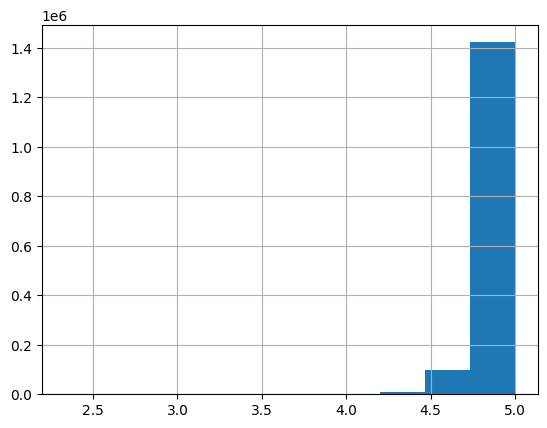

In [62]:
final_table_taxi_filtered.driver_rating.hist()

<Axes: >

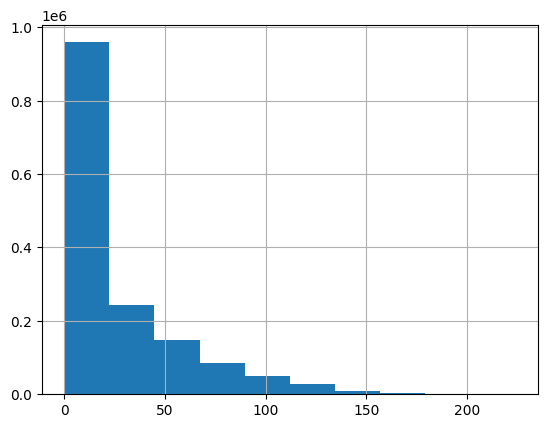

In [63]:
final_table_taxi_filtered.gold_level_count.hist()

In [64]:
final_table_taxi_filtered.gold_level_count.describe()

count    1527512.0
mean     25.500162
std      32.171083
min            0.0
25%            2.0
50%           12.0
75%           38.0
max          224.0
Name: gold_level_count, dtype: Float64

In [65]:
final_table_taxi_filtered.driver_rating.describe()

count    1.527512e+06
mean     4.890591e+00
std      1.015809e-01
min      2.330000e+00
25%      4.860000e+00
50%      4.920000e+00
75%      4.960000e+00
max      5.000000e+00
Name: driver_rating, dtype: float64

lets setup here level too: below 4.8, 4.8 - 4.96, above 4.96 and the same for gold levels

In [66]:
final_table_taxi_filtered['rating_adjusted'] = final_table_taxi_filtered.driver_rating.apply(
        lambda x: "below 4.8" if x < 4.8 else
                  "4.96+" if x > 4.96 else
                  "average")
final_table_taxi_filtered['gold_adjusted'] = final_table_taxi_filtered.gold_level_count.apply(
        lambda x: "below 2" if x < 2 else
                  "38+" if x > 38 else
                  "average")

In [67]:
final_table_taxi_filtered

,id_driver,active_date,offers_level,rides_level,bookings_cancelled_by_passenger_level,bookings_cancelled_by_driver_level,offers_CR_ride_level,accept_offer_rate_level,cancelled_by_driver_rate_level,cancelled_by_passenger_rate_level,driver_rating,gold_level_count,receive_marketing,country_code,service_type,both_service_type,diff_days,diff_years,rating_adjusted,gold_adjusted
0,3,2020-01-01,below average,above average,above average,above average,almost average,almost average,above average,above average,4.87,22,True,DE,TAXI,False,3139,9.0,average,average
1,3,2020-01-02,below average,almost average,almost average,above average,almost average,above average,above average,almost average,4.87,22,True,DE,TAXI,False,3140,9.0,average,average
2,3,2020-01-03,almost average,almost average,almost average,almost average,above average,above average,below average,almost average,4.87,22,True,DE,TAXI,False,3141,9.0,average,average
3,3,2020-01-05,below average,almost average,below average,above average,almost average,above average,above average,almost average,4.87,22,True,DE,TAXI,False,3143,9.0,average,average
4,3,2020-01-06,below average,almost average,almost average,almost average,above average,above average,above average,almost average,4.87,22,True,DE,TAXI,False,3144,9.0,average,average
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1792670,58980064,2020-06-27,almost average,below average,below average,almost average,below average,below average,below average,almost average,4.87,0,False,ES,TAXI,False,1,0.0,average,below 2
1792671,58980278,2020-06-26,almost average,almost average,almost average,almost average,below average,below average,almost average,below average,5.00,0,True,ES,TAXI,False,0,0.0,4.96+,below 2
1792672,58980278,2020-06-28,above average,above average,almost average,almost average,below average,below average,below average,below average,5.00,0,True,ES,TAXI,False,2,0.0,4.96+,below 2
1792673,58980278,2020-06-29,almost average,almost average,almost average,almost average,almost average,below average,below average,below average,5.00,0,True,ES,TAXI,False,3,0.0,4.96+,below 2


now lets do the same for private hiring

In [68]:
final_table_private_filtered.gold_level_count.describe()

count    277086.0
mean     3.721112
std      9.586301
min           0.0
25%           0.0
50%           0.0
75%           4.0
max         173.0
Name: gold_level_count, dtype: Float64

In [69]:
final_table_private_filtered.driver_rating.describe()

count    277086.000000
mean          4.917112
std           0.078206
min           3.500000
25%           4.890000
50%           4.940000
75%           4.970000
max           5.000000
Name: driver_rating, dtype: float64

In [70]:
final_table_private_filtered['rating_adjusted'] = final_table_private_filtered.driver_rating.apply(
        lambda x: "below 4.89" if x < 4.89 else
                  "4.97+" if x > 4.97 else
                  "average")
final_table_private_filtered['gold_adjusted'] = final_table_private_filtered.gold_level_count.apply(
        lambda x: "0 or 1" if x < 1 else
                  "4+")

In [71]:
final_table_taxi_filtered.offers_level.value_counts()

offers_level
almost average    763236
below average     414664
above average     349612
Name: count, dtype: int64

In [72]:
final_table_taxi_filtered.columns

Index(['id_driver', 'active_date', 'offers_level', 'rides_level',
       'bookings_cancelled_by_passenger_level',
       'bookings_cancelled_by_driver_level', 'offers_CR_ride_level',
       'accept_offer_rate_level', 'cancelled_by_driver_rate_level',
       'cancelled_by_passenger_rate_level', 'driver_rating',
       'gold_level_count', 'receive_marketing', 'country_code', 'service_type',
       'both_service_type', 'diff_days', 'diff_years', 'rating_adjusted',
       'gold_adjusted'],
      dtype='object')

In [73]:
final_table_taxi_filtered = final_table_taxi_filtered.rename(columns={'offers_level': 'relative_number_offers_received', 
                                          'rides_level': 'relative_number_rides_completed',
                                          'offers_CR_ride_level': 'relative_full_conversion', 
                                          'bookings_cancelled_by_passenger_level': 'relative_number_cancellations_by_passenger',
                                          'bookings_cancelled_by_driver_level': 'relative_number_cancellations_by_driver'})
final_table_private_filtered = final_table_taxi_filtered.rename(columns={'offers_level': 'relative_number_offers_received', 
                                          'rides_level': 'relative_number_rides_completed',
                                          'offers_CR_ride_level': 'relative_full_conversion',
                                          'bookings_cancelled_by_passenger_level': 'relative_number_cancellations_by_passenger',
                                          'bookings_cancelled_by_driver_level': 'relative_number_cancellations_by_driver'})

In [74]:
def plot_stacked_bar_proportions(df, dimension, level_column, title=None):
    level_order = ['below average', 'almost average', 'above average']
    freenow_colors = {
        'below average': '#E5E5E5',
        'almost average': '#001E3E',
        'above average': '#FF0033'
    }

    df_name = ''
    if df is final_table_taxi_filtered:
        df_name = 'taxi'
    elif df is final_table_private_filtered:
        df_name = 'phv'
    else:
        df_name = 'data'
    grouped = df.groupby([dimension, level_column])['id_driver'].count().unstack(fill_value=0)
    proportions = grouped.div(grouped.sum(axis=1), axis=0)
    proportions.plot(kind='bar', stacked=True, color=[freenow_colors[level] for level in level_order], figsize=(12, 8))
    plt.ylabel("Proportion of Drivers")
    plt.title((title or f"Proportion of {level_column.replace('_', ' ').title()} by {dimension.replace('_', ' ').title()}") + f" ({df_name})")
    plt.xticks(rotation=45)
    plt.legend(title=level_column.replace("_", " ").title(), bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

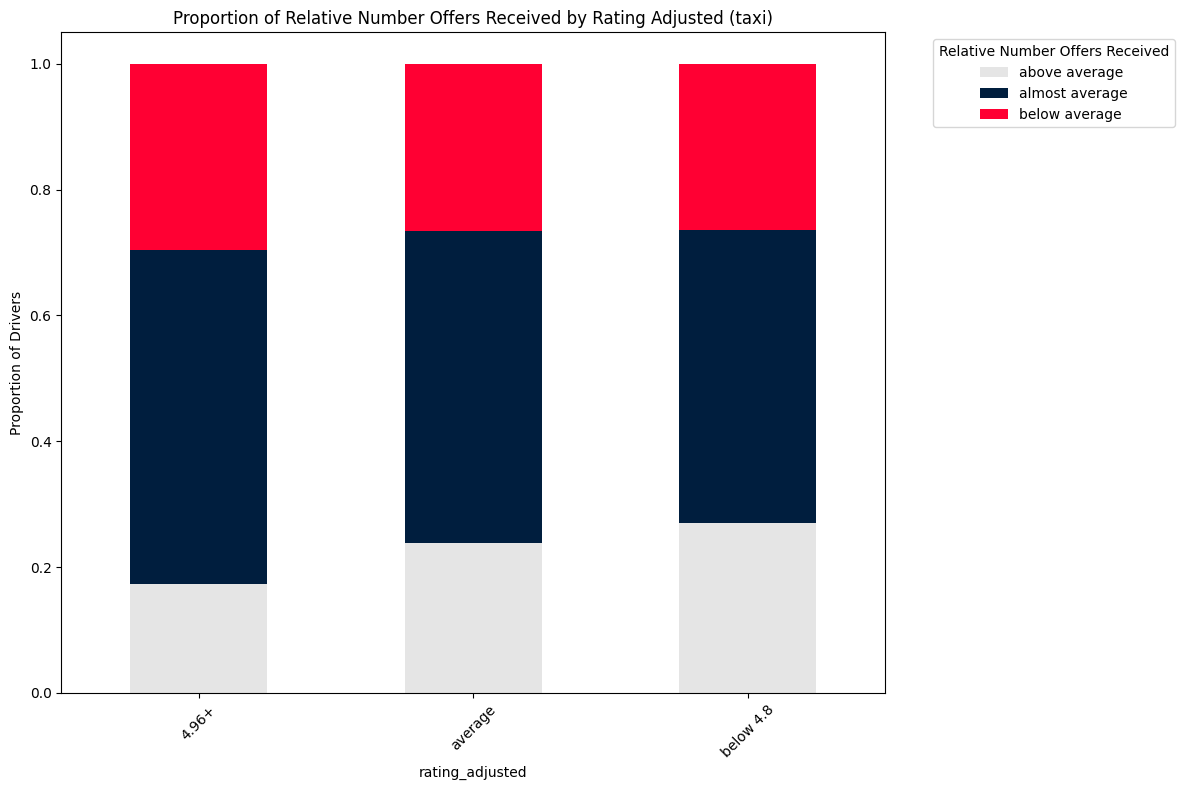

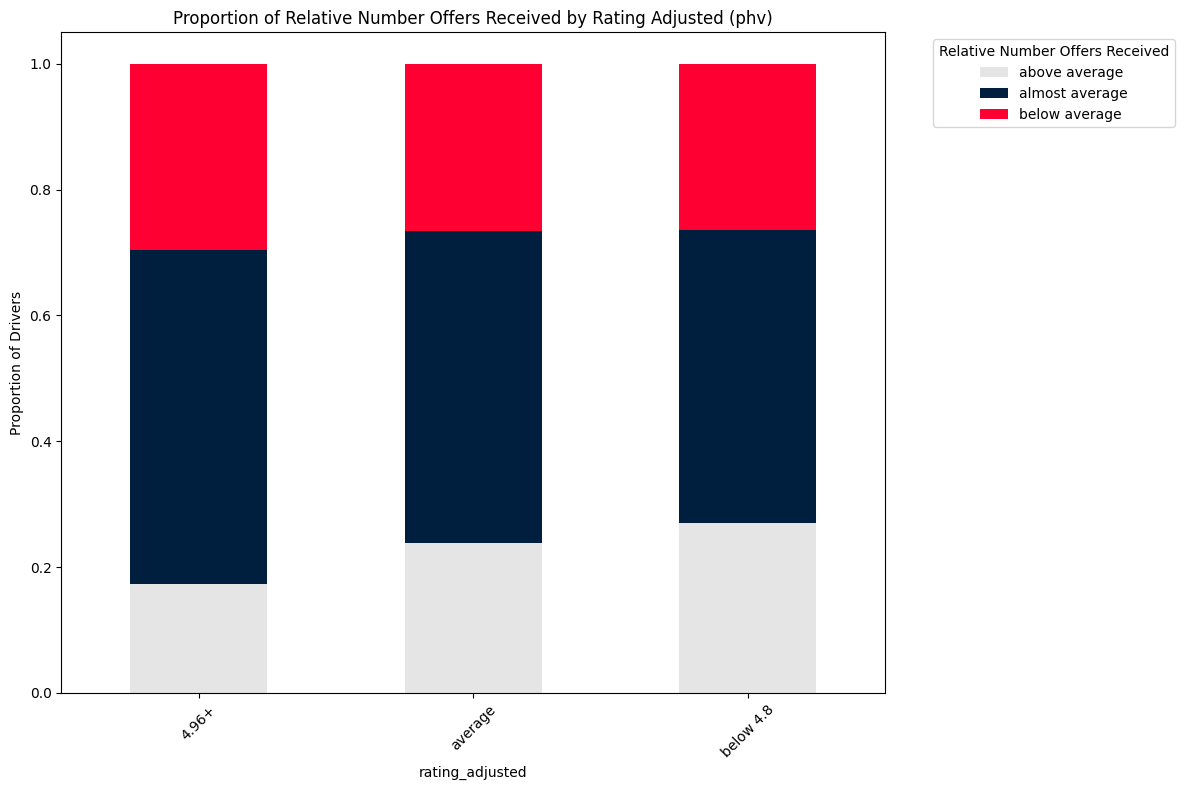

In [75]:
plot_stacked_bar_proportions(final_table_taxi_filtered, 'rating_adjusted', 'relative_number_offers_received')
plot_stacked_bar_proportions(final_table_private_filtered, 'rating_adjusted', 'relative_number_offers_received')

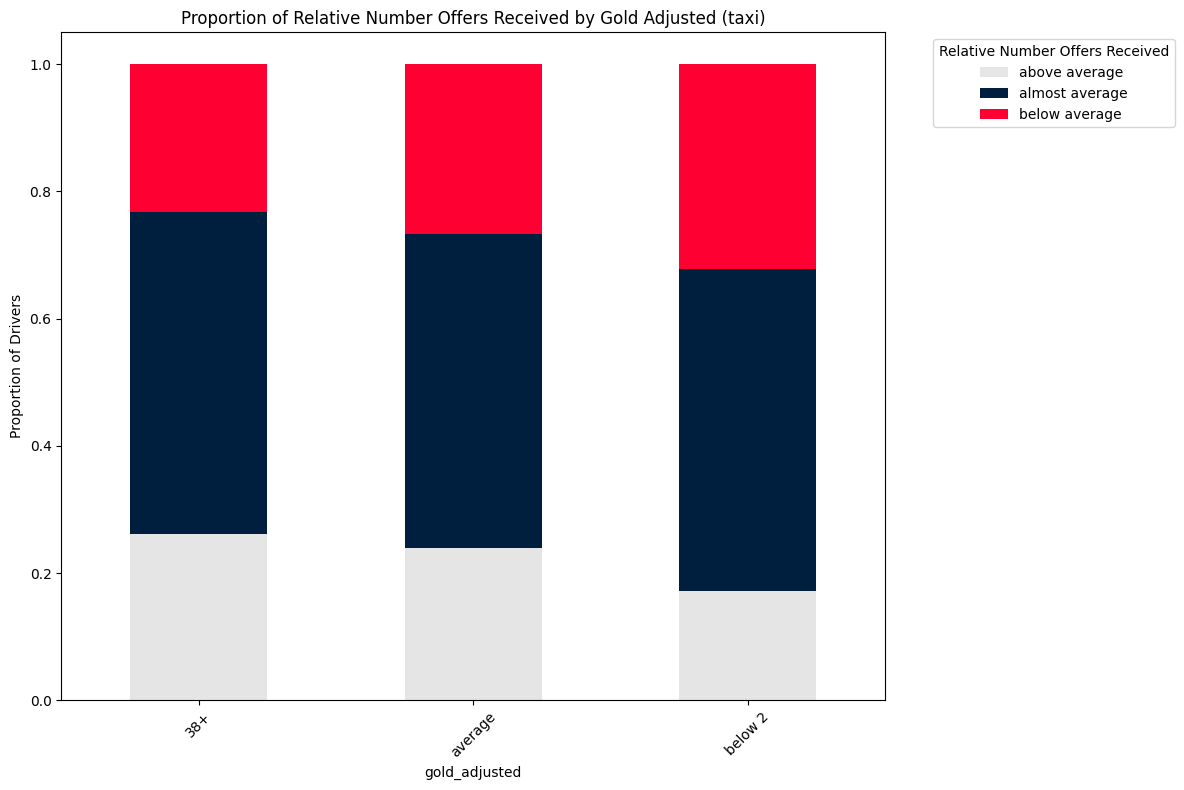

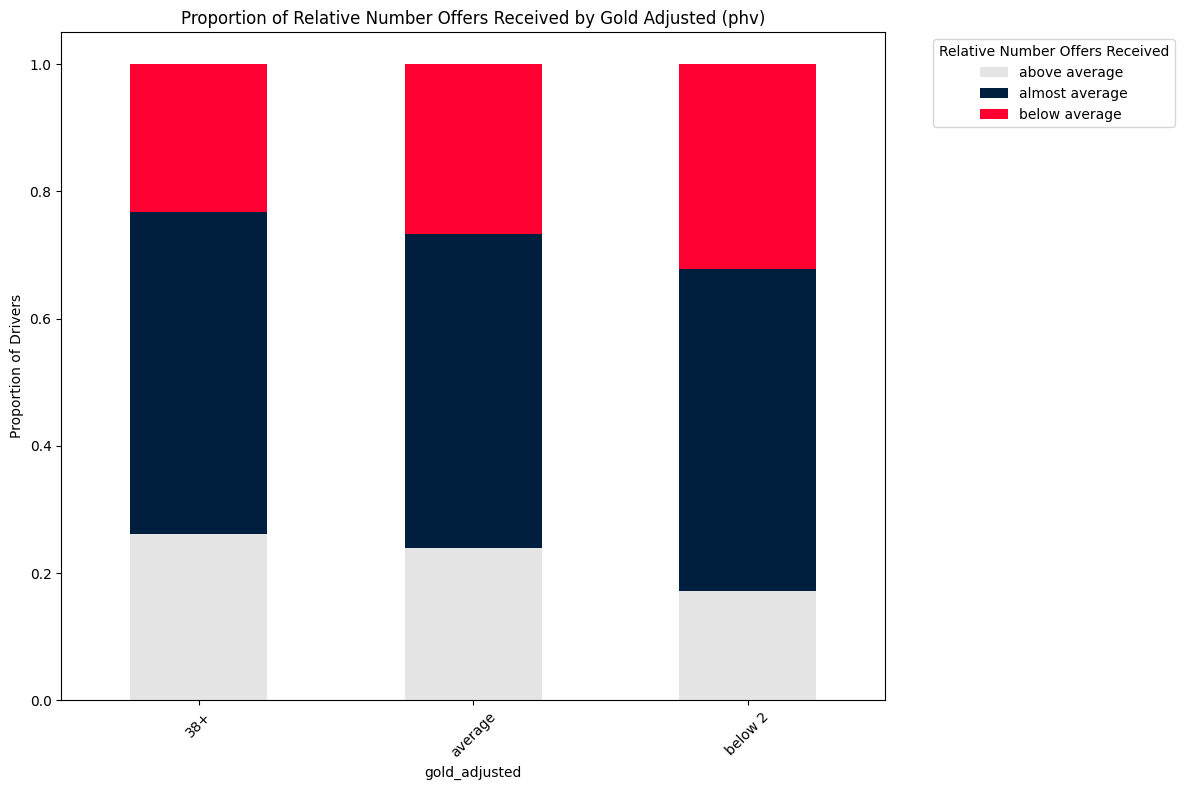

In [76]:
plot_stacked_bar_proportions(final_table_taxi_filtered, 'gold_adjusted', 'relative_number_offers_received')
plot_stacked_bar_proportions(final_table_private_filtered, 'gold_adjusted', 'relative_number_offers_received')

What i find interesting in these 2 plots is that gold wins really help to get more offers for drivers, but mostly in regular taxi, in private there is no big difference between average performers and exceptional. 

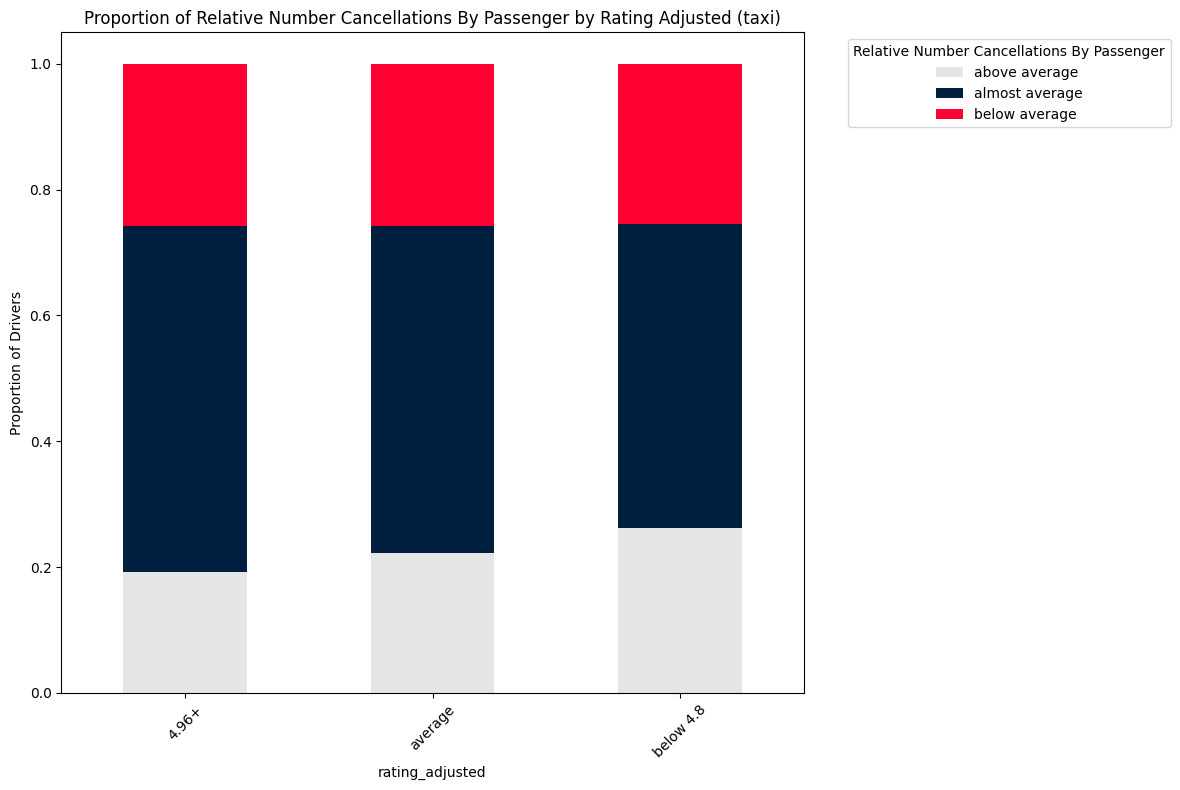

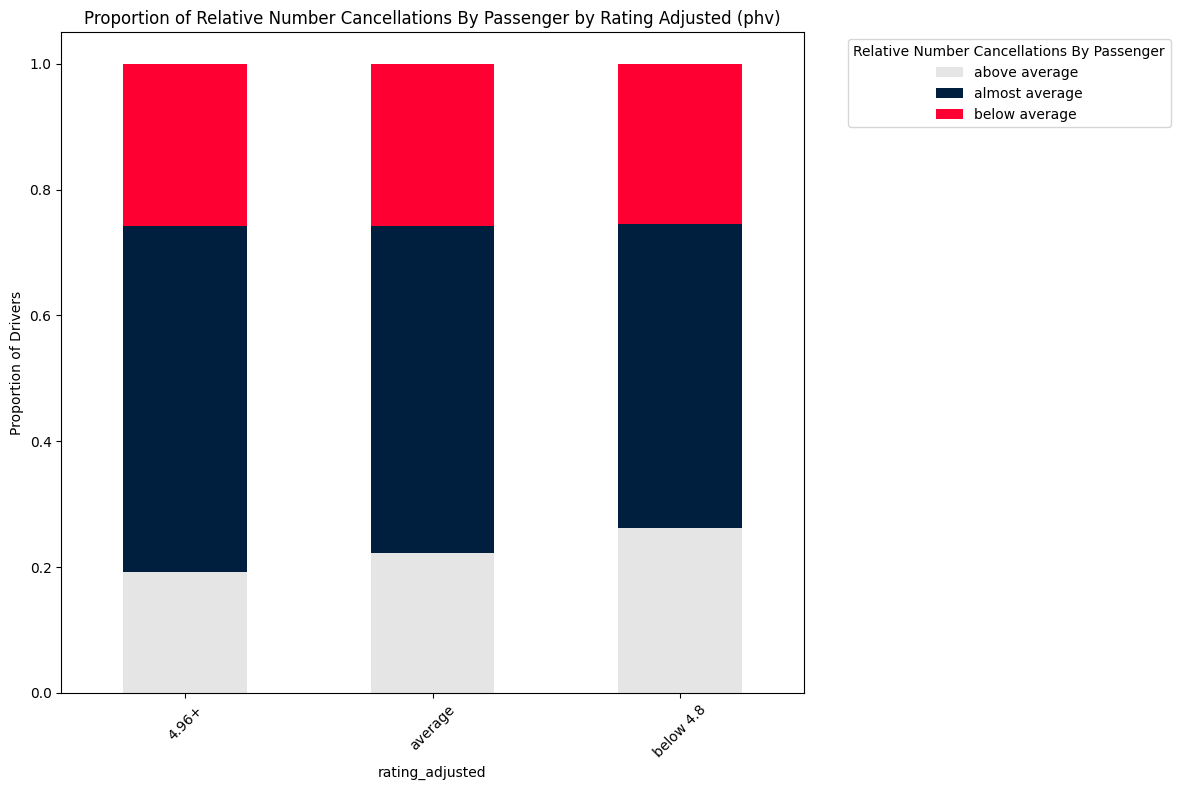

In [77]:
plot_stacked_bar_proportions(final_table_taxi_filtered, 'rating_adjusted', 'relative_number_cancellations_by_passenger')
plot_stacked_bar_proportions(final_table_private_filtered, 'rating_adjusted', 'relative_number_cancellations_by_passenger')

This is not exactly correlation, but rather a loop: more cancellations by customers might lead to lower rating for driver, and the same the other way - lower rating might lead to higher number of cacelations done by passengers

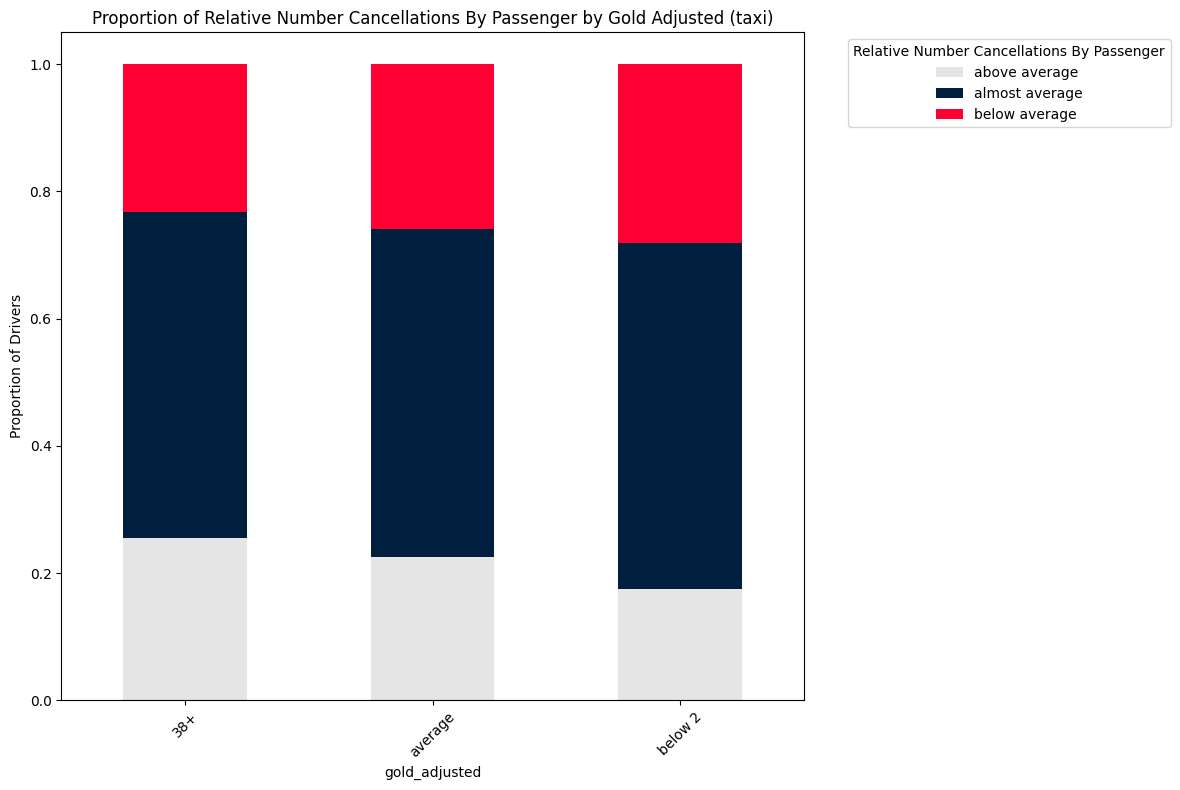

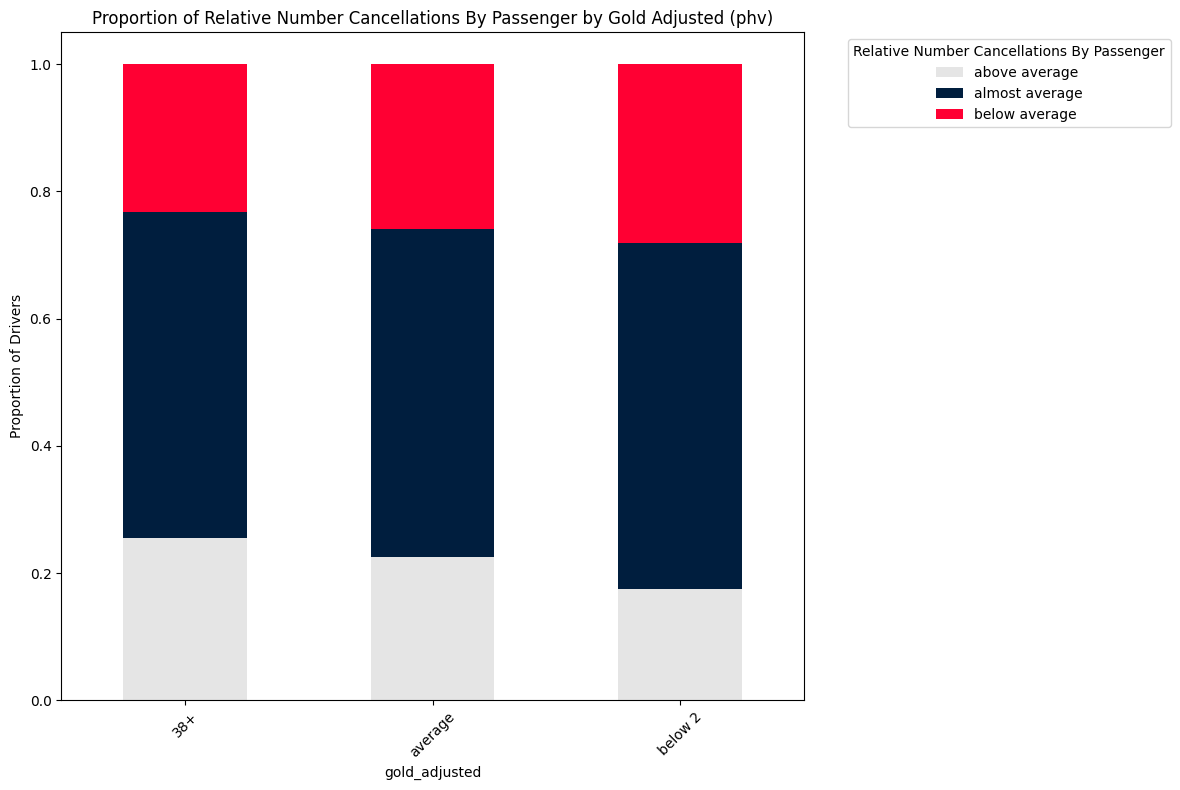

In [78]:
plot_stacked_bar_proportions(final_table_taxi_filtered, 'gold_adjusted', 'relative_number_cancellations_by_passenger')
plot_stacked_bar_proportions(final_table_private_filtered, 'gold_adjusted', 'relative_number_cancellations_by_passenger')

It looks like here higher proporting of cancelations with top performers might be issued by higher number of offers and possibilities to cancel the ride

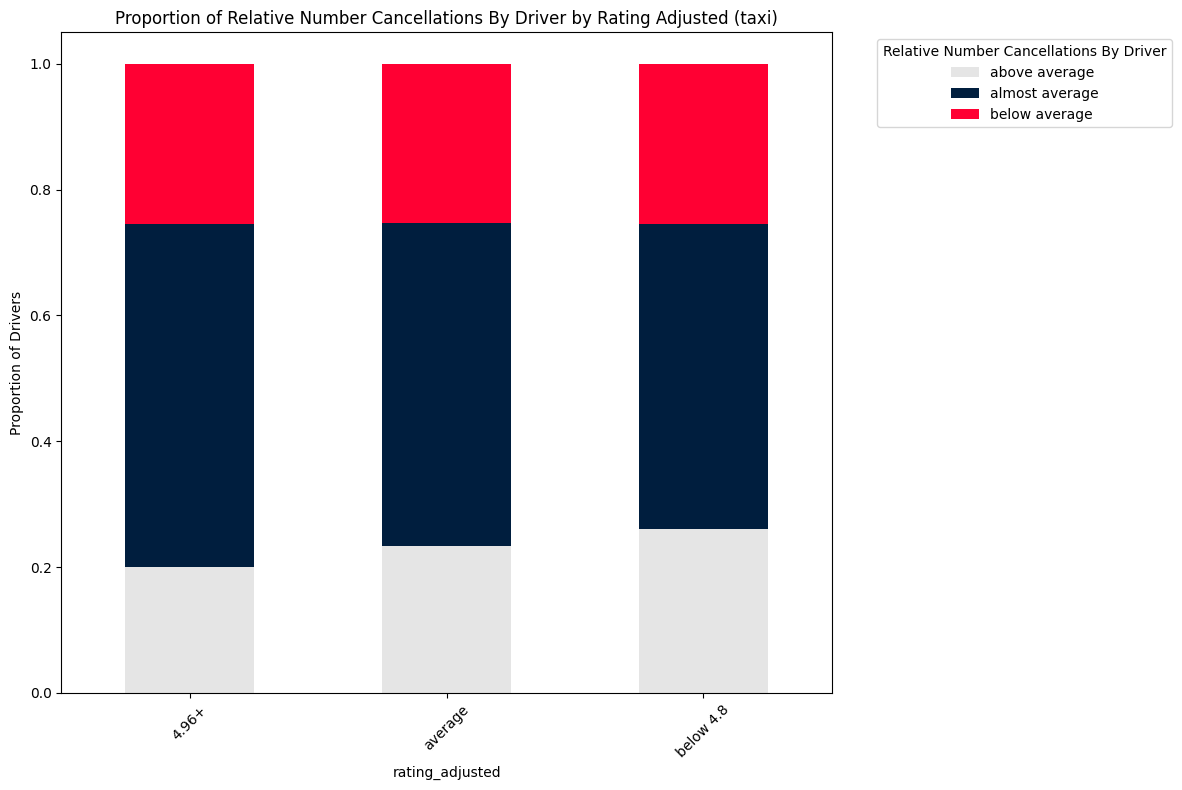

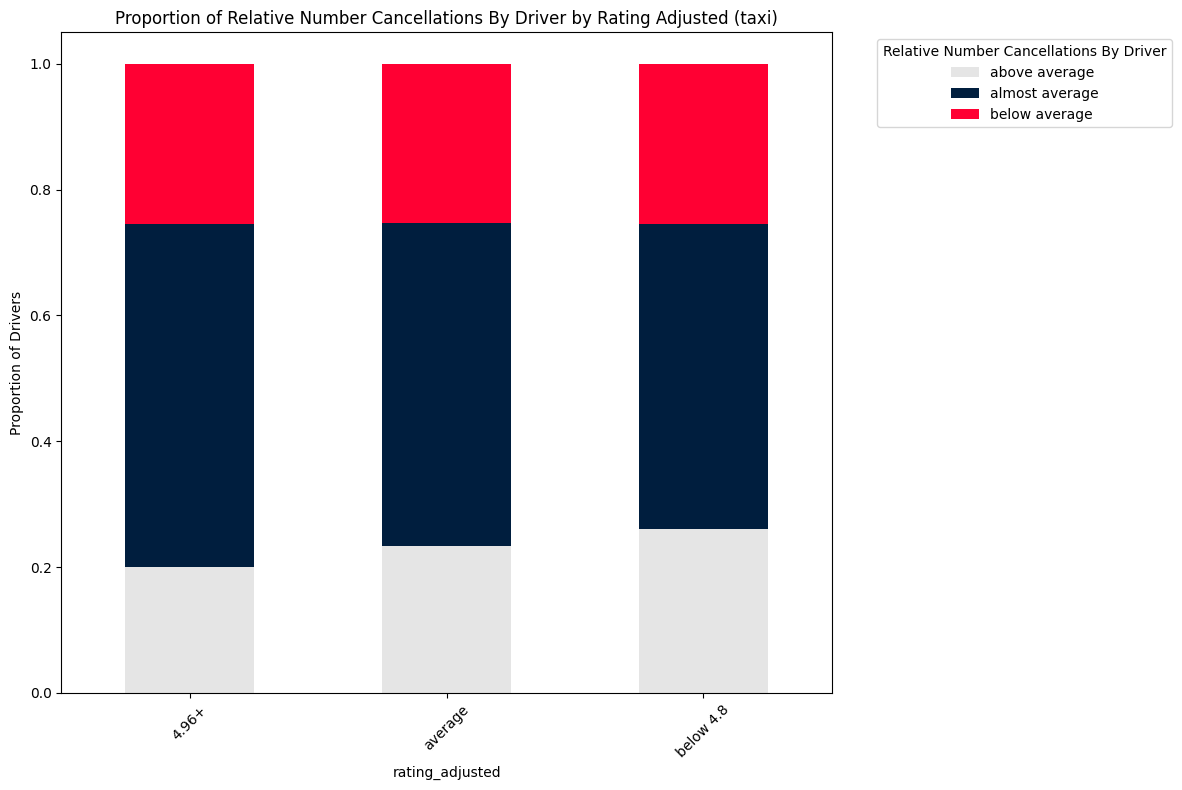

In [79]:
plot_stacked_bar_proportions(final_table_taxi_filtered, 'rating_adjusted', 'relative_number_cancellations_by_driver')
plot_stacked_bar_proportions(final_table_taxi_filtered, 'rating_adjusted', 'relative_number_cancellations_by_driver')

So, what we see here, is that drivers with lower rating tend to cancel rides a bit more frequently

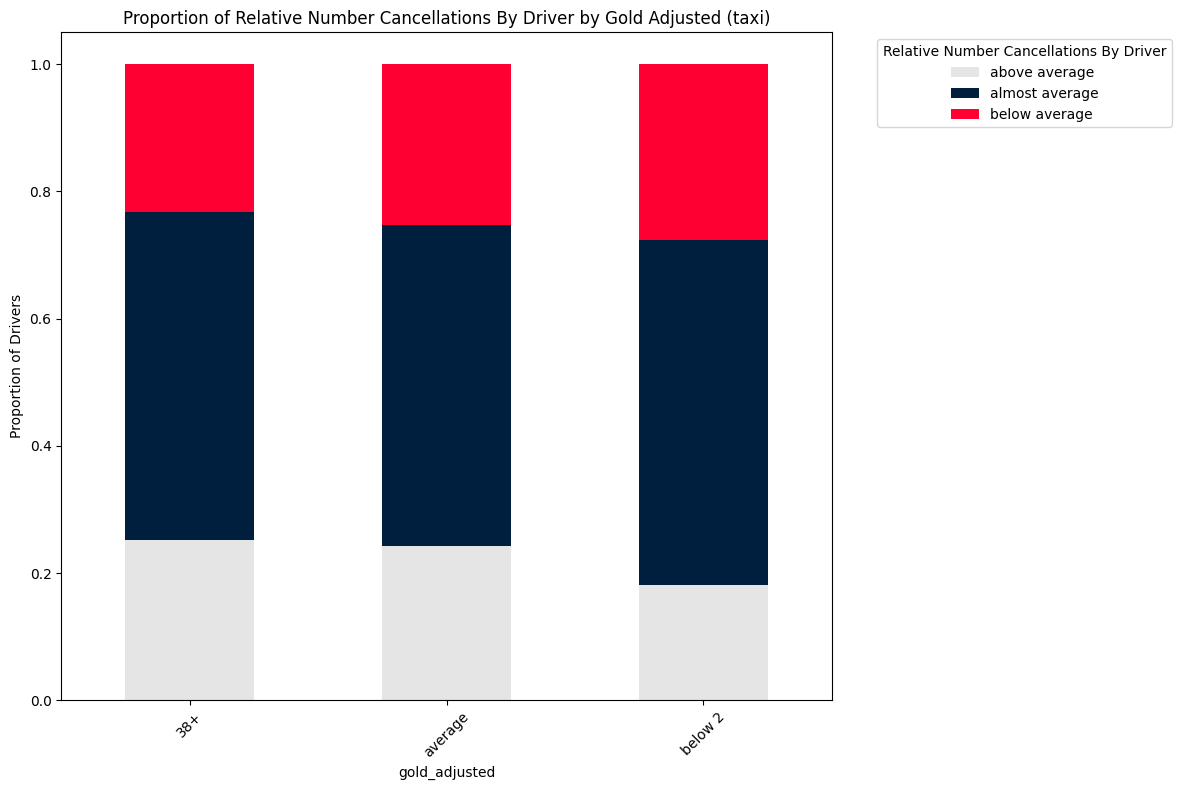

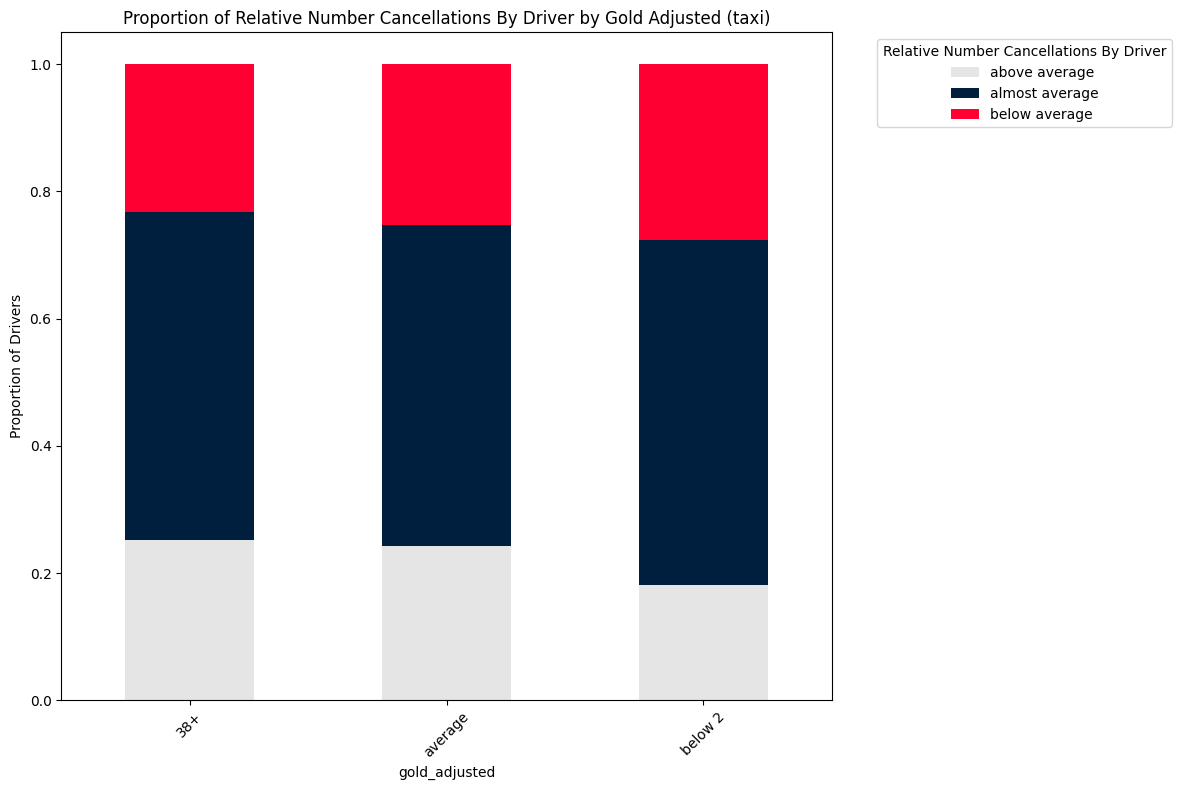

In [80]:
plot_stacked_bar_proportions(final_table_taxi_filtered, 'gold_adjusted', 'relative_number_cancellations_by_driver')
plot_stacked_bar_proportions(final_table_taxi_filtered, 'gold_adjusted', 'relative_number_cancellations_by_driver')

Here is the same logic, i guess, more rides = more cancelations

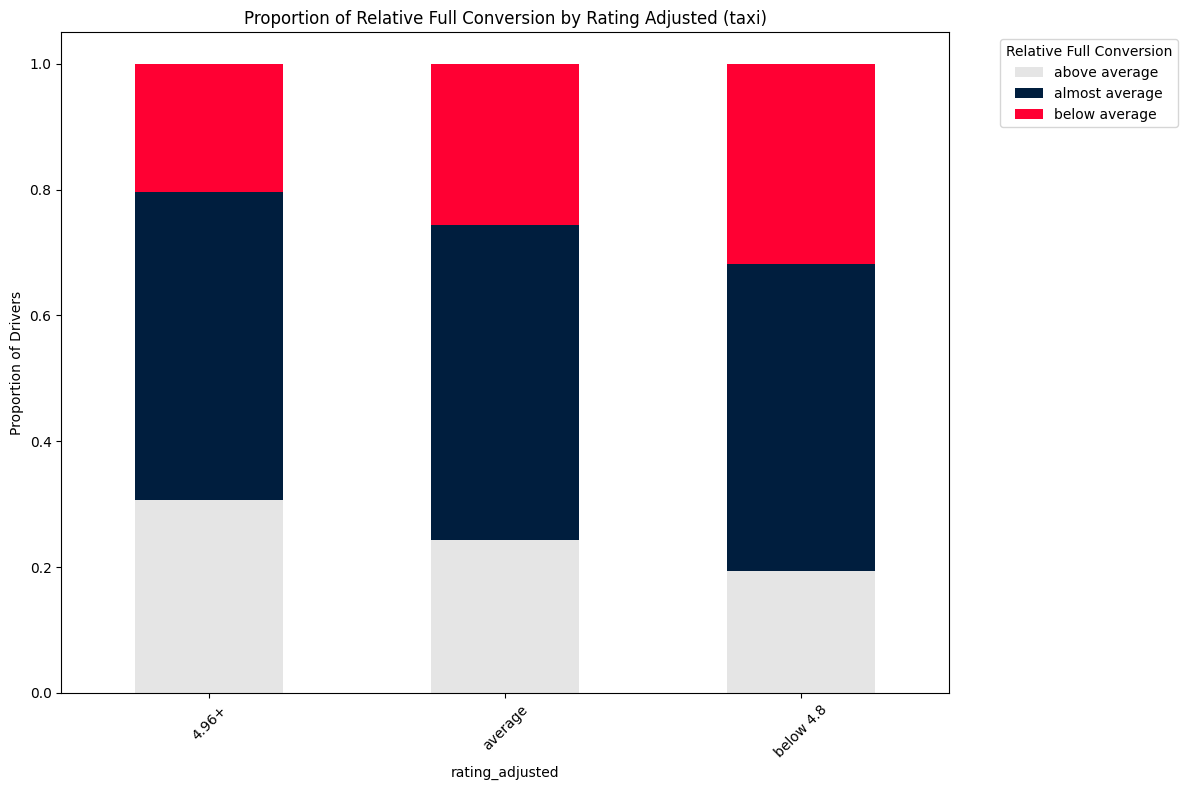

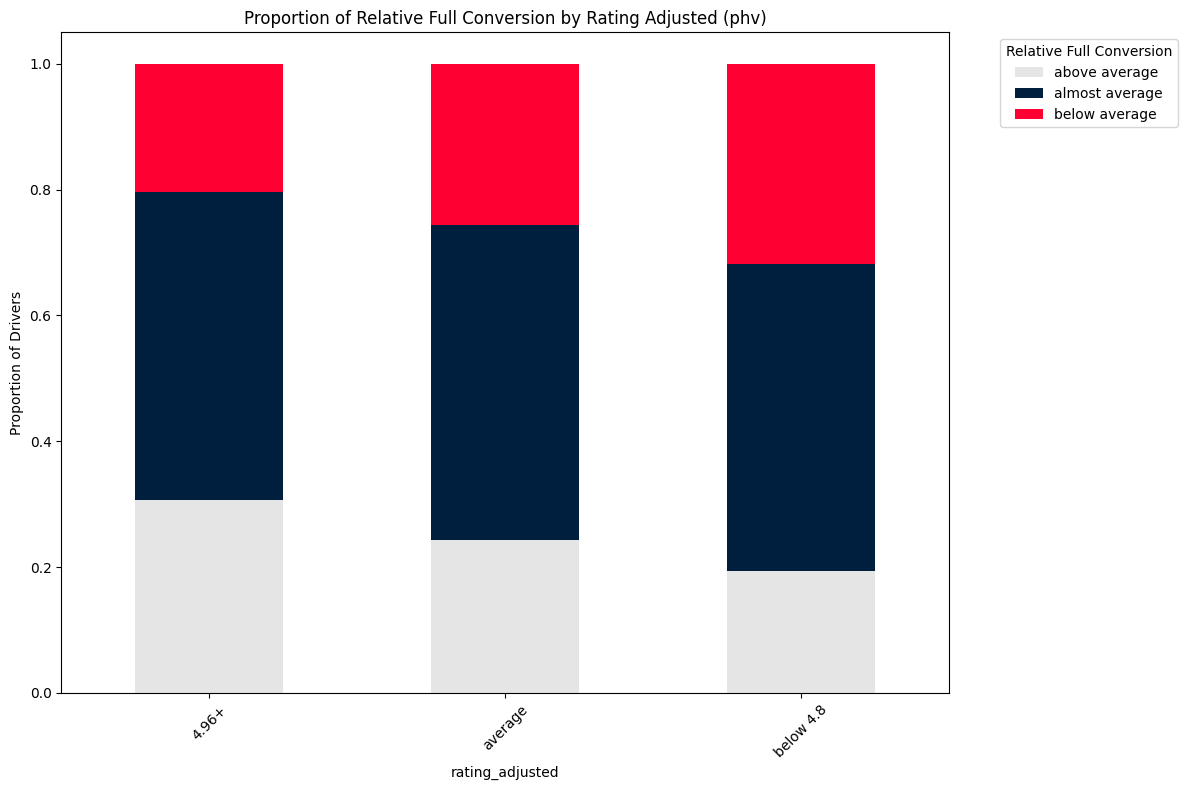

In [81]:
plot_stacked_bar_proportions(final_table_taxi_filtered, 'rating_adjusted', 'relative_full_conversion')
plot_stacked_bar_proportions(final_table_private_filtered, 'rating_adjusted', 'relative_full_conversion')

This is very important for us, the higher rating of the driver - the higher chance we get for conversion from offer to actual ride. THis is a good indicator

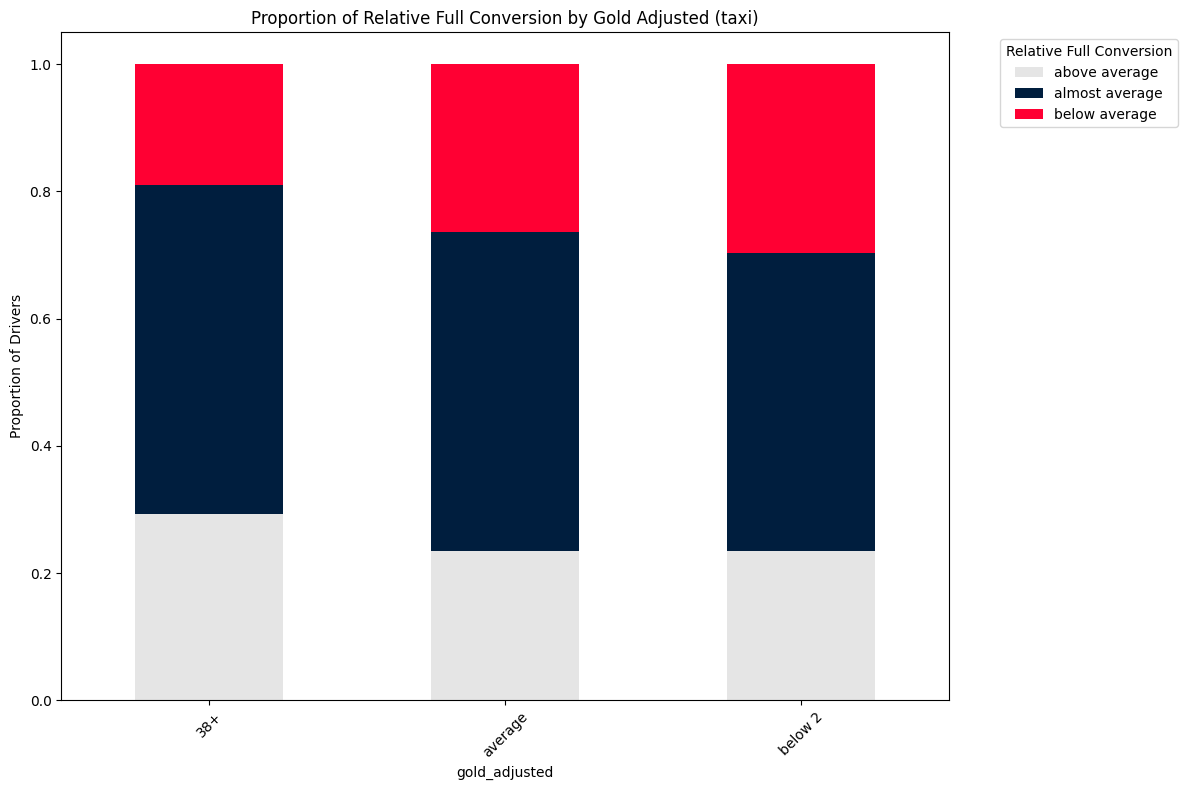

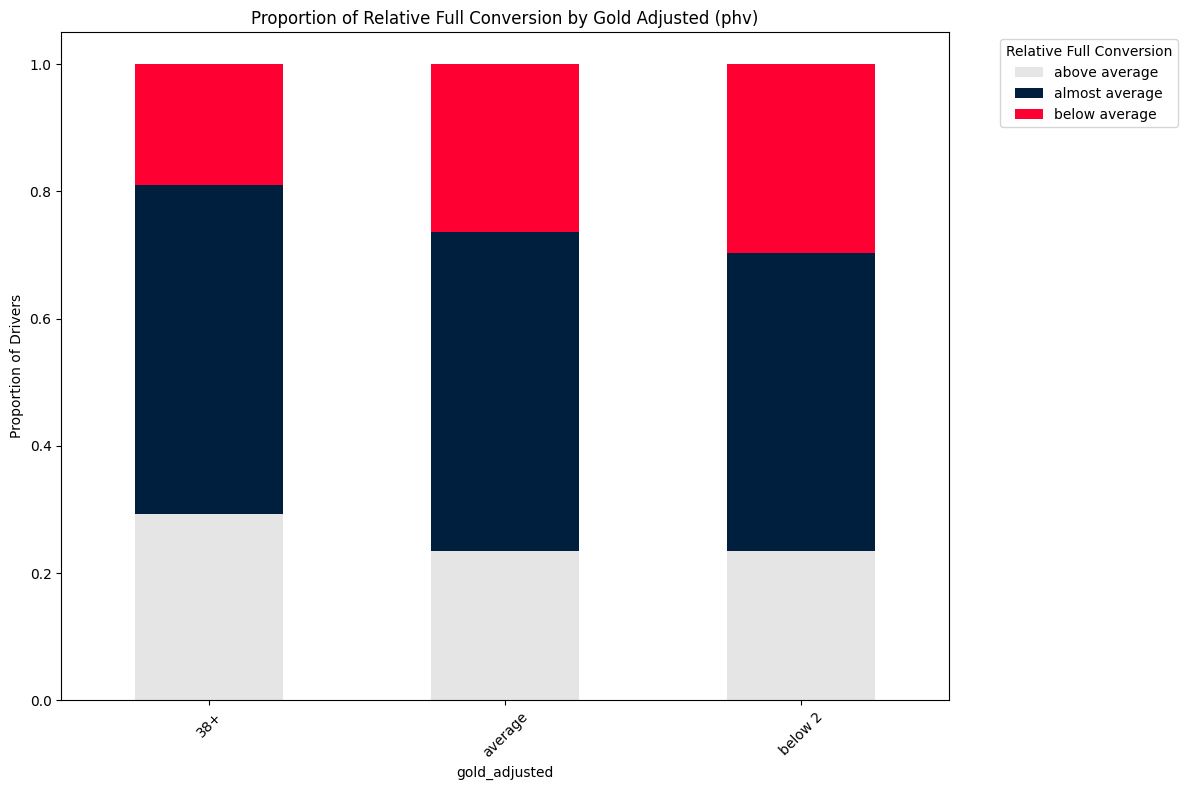

In [82]:
plot_stacked_bar_proportions(final_table_taxi_filtered, 'gold_adjusted', 'relative_full_conversion')
plot_stacked_bar_proportions(final_table_private_filtered, 'gold_adjusted', 'relative_full_conversion')

Same refferes to gold awards, top performers have higher CR

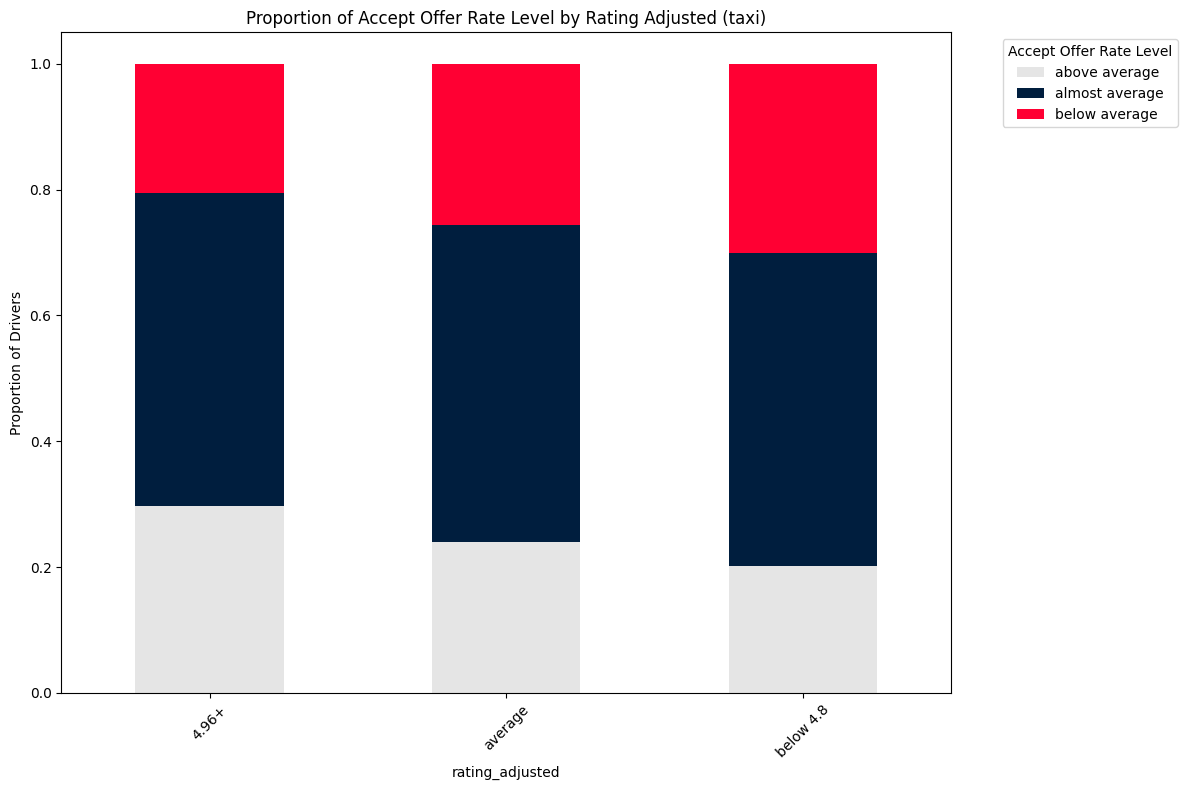

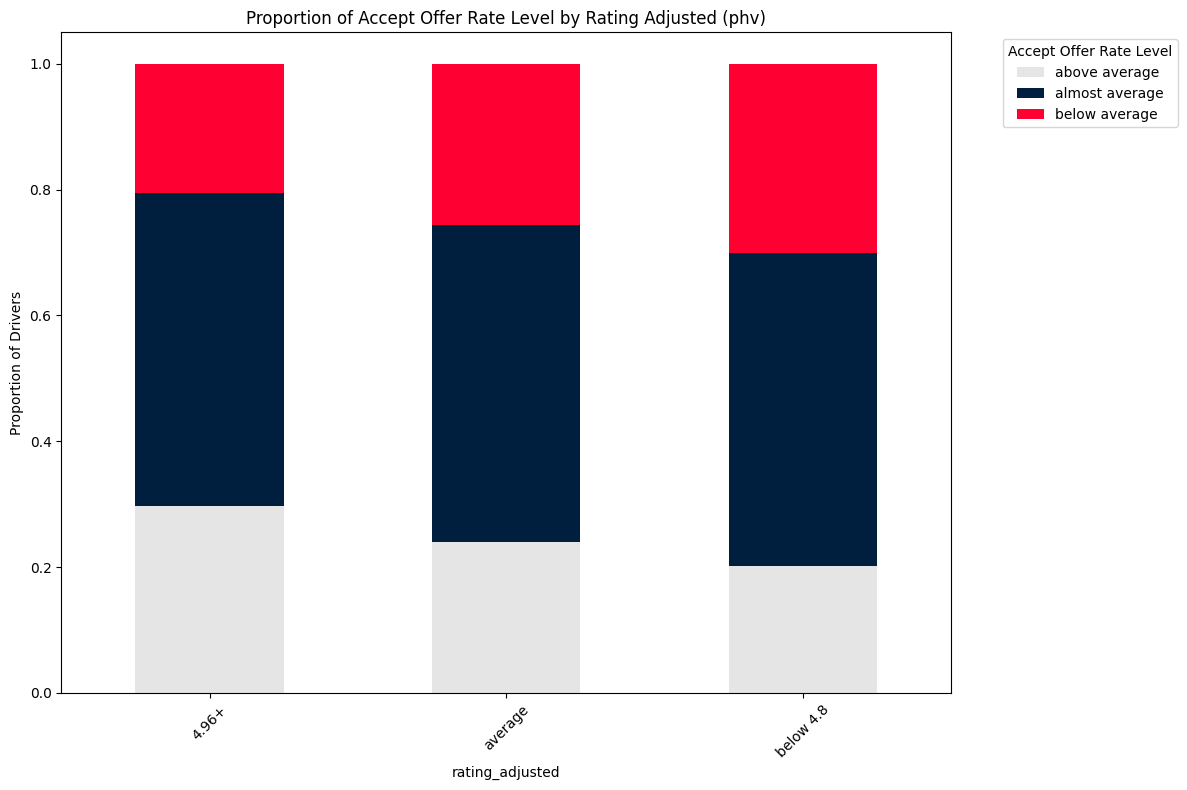

In [83]:
plot_stacked_bar_proportions(final_table_taxi_filtered, 'rating_adjusted', 'accept_offer_rate_level')
plot_stacked_bar_proportions(final_table_private_filtered, 'rating_adjusted', 'accept_offer_rate_level')

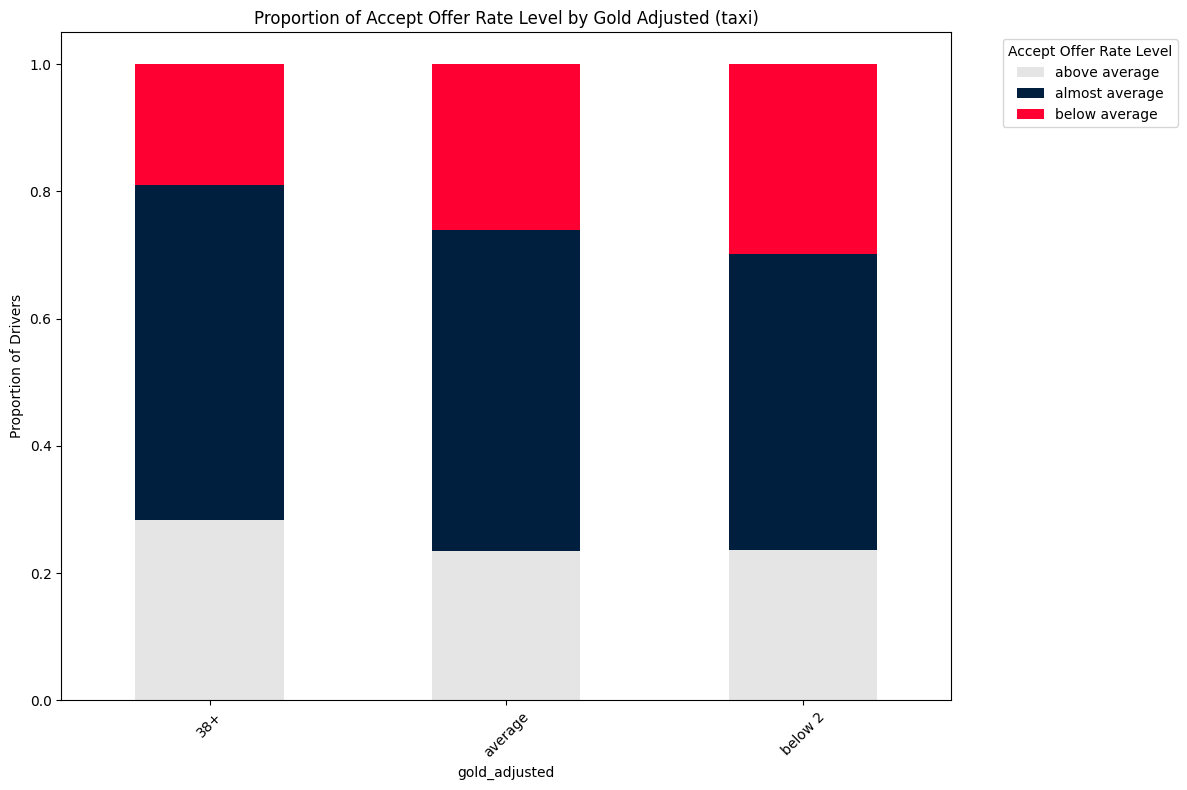

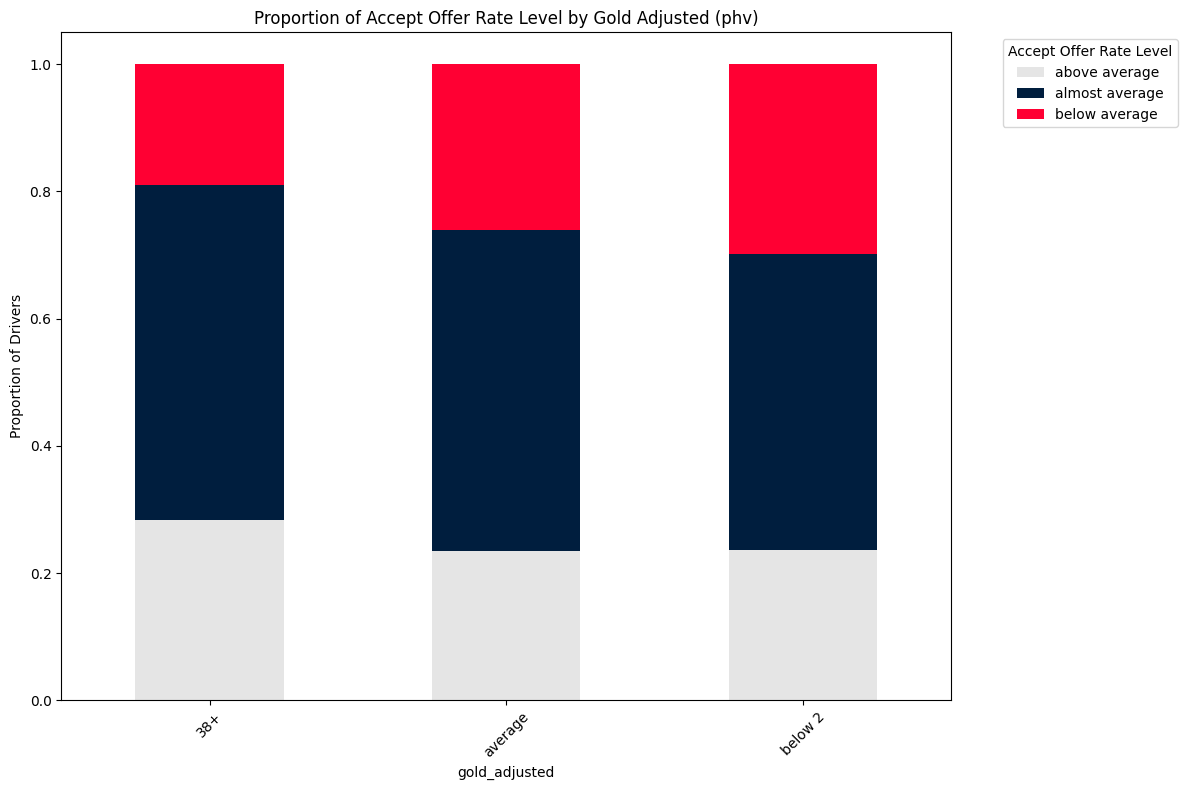

In [84]:
plot_stacked_bar_proportions(final_table_taxi_filtered, 'gold_adjusted', 'accept_offer_rate_level')
plot_stacked_bar_proportions(final_table_private_filtered, 'gold_adjusted', 'accept_offer_rate_level')

With accepting offers picture is the same, top performes and people with high rating have higher chance of accepting offer and conversion 

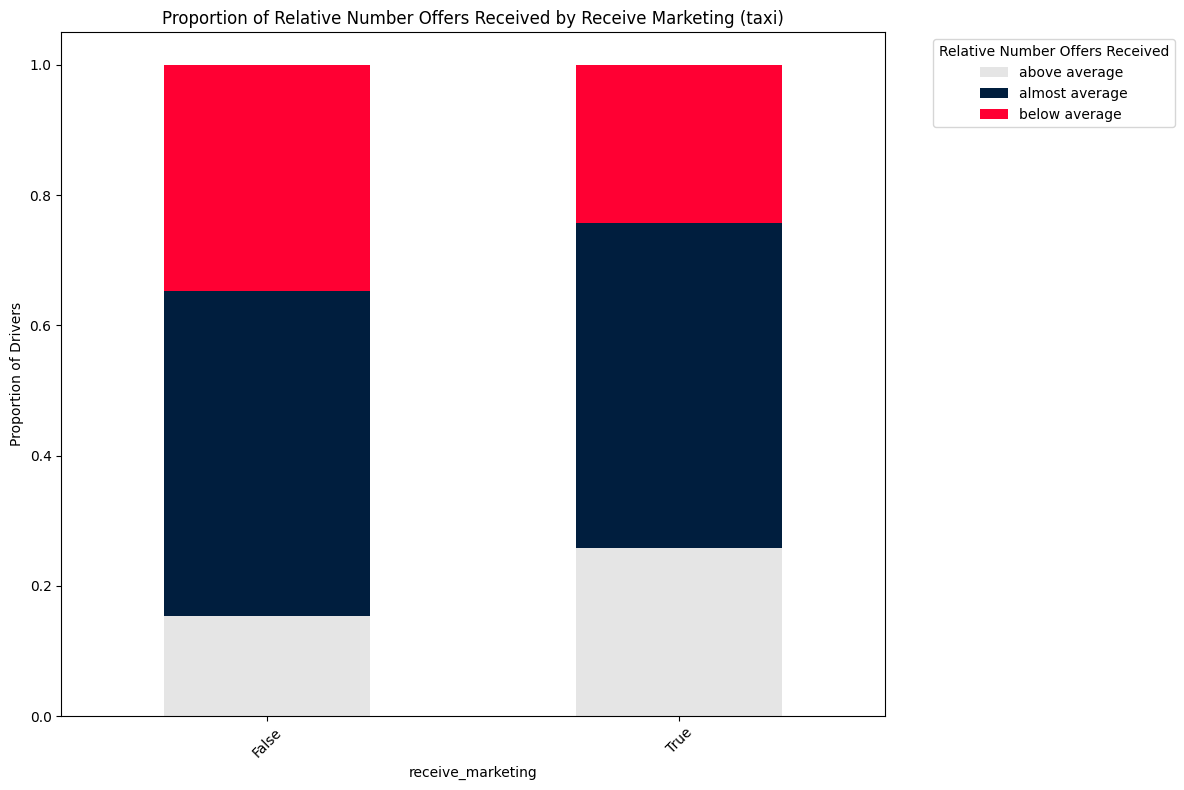

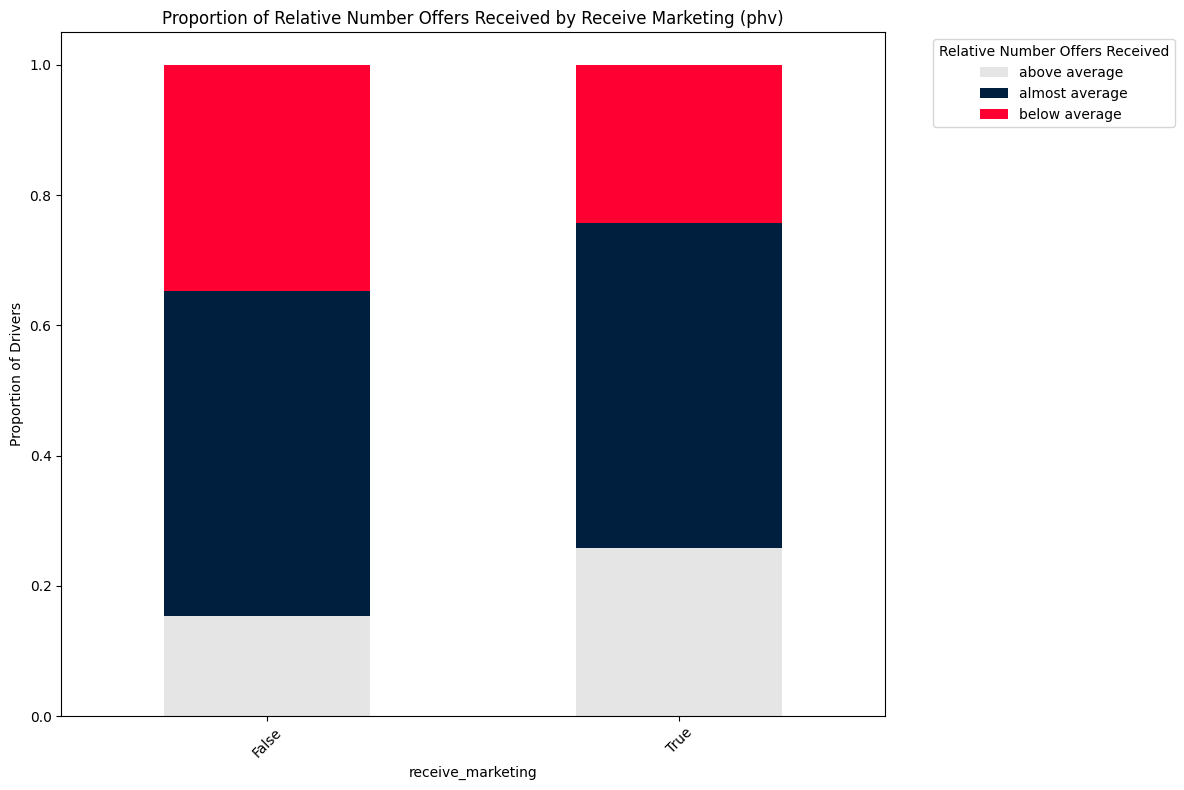

In [85]:
plot_stacked_bar_proportions(final_table_taxi_filtered, 'receive_marketing', 'relative_number_offers_received')
plot_stacked_bar_proportions(final_table_private_filtered, 'receive_marketing', 'relative_number_offers_received')

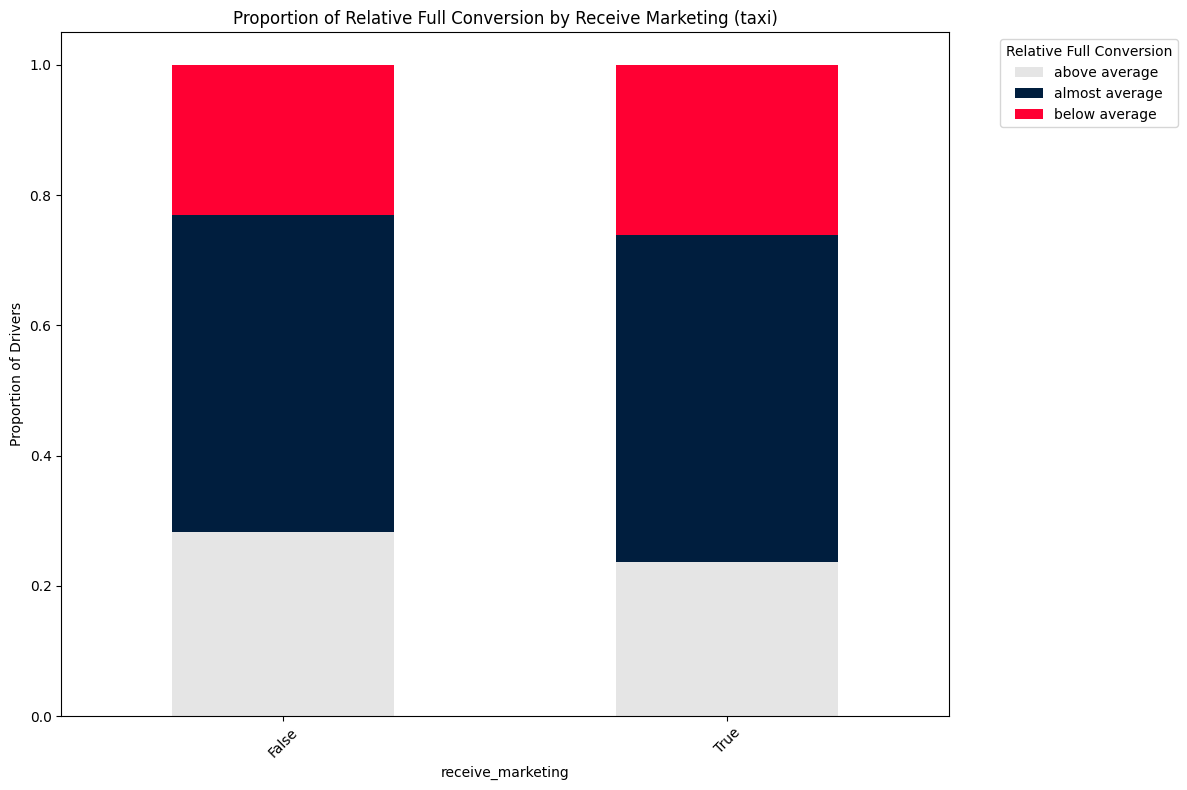

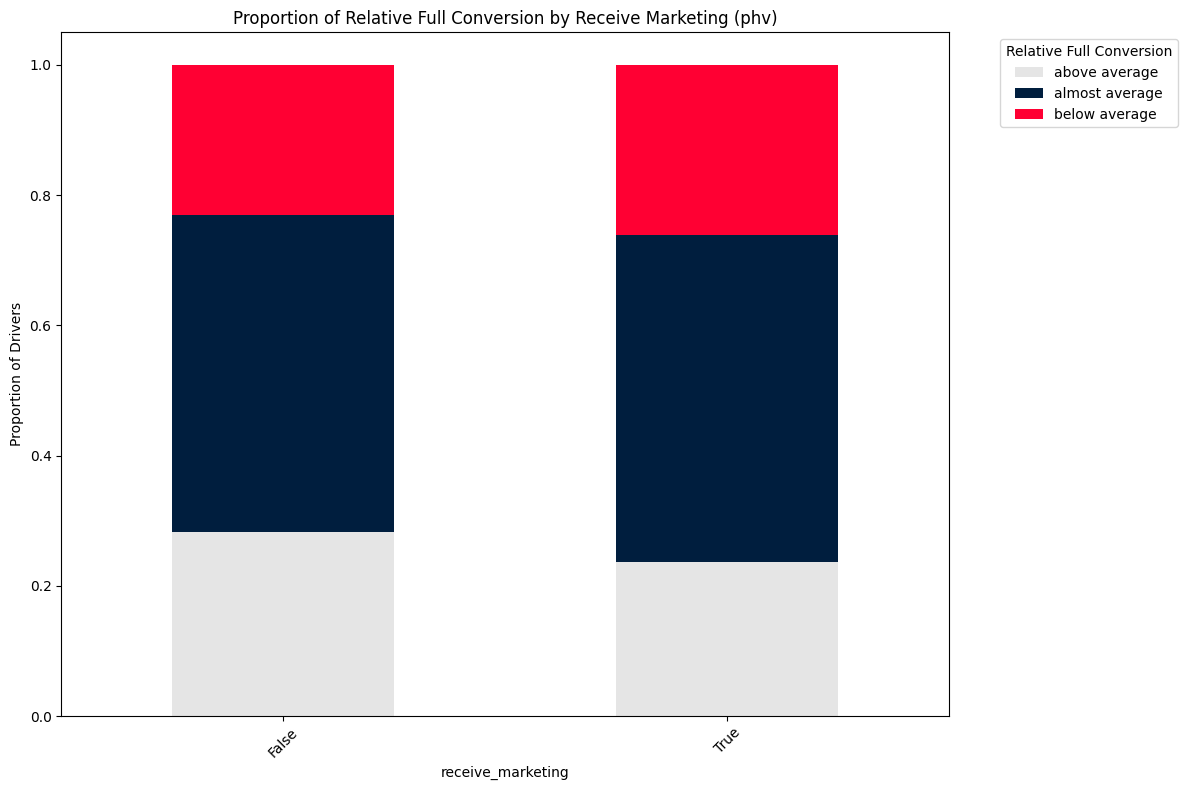

In [86]:
plot_stacked_bar_proportions(final_table_taxi_filtered, 'receive_marketing', 'relative_full_conversion')
plot_stacked_bar_proportions(final_table_private_filtered, 'receive_marketing', 'relative_full_conversion')

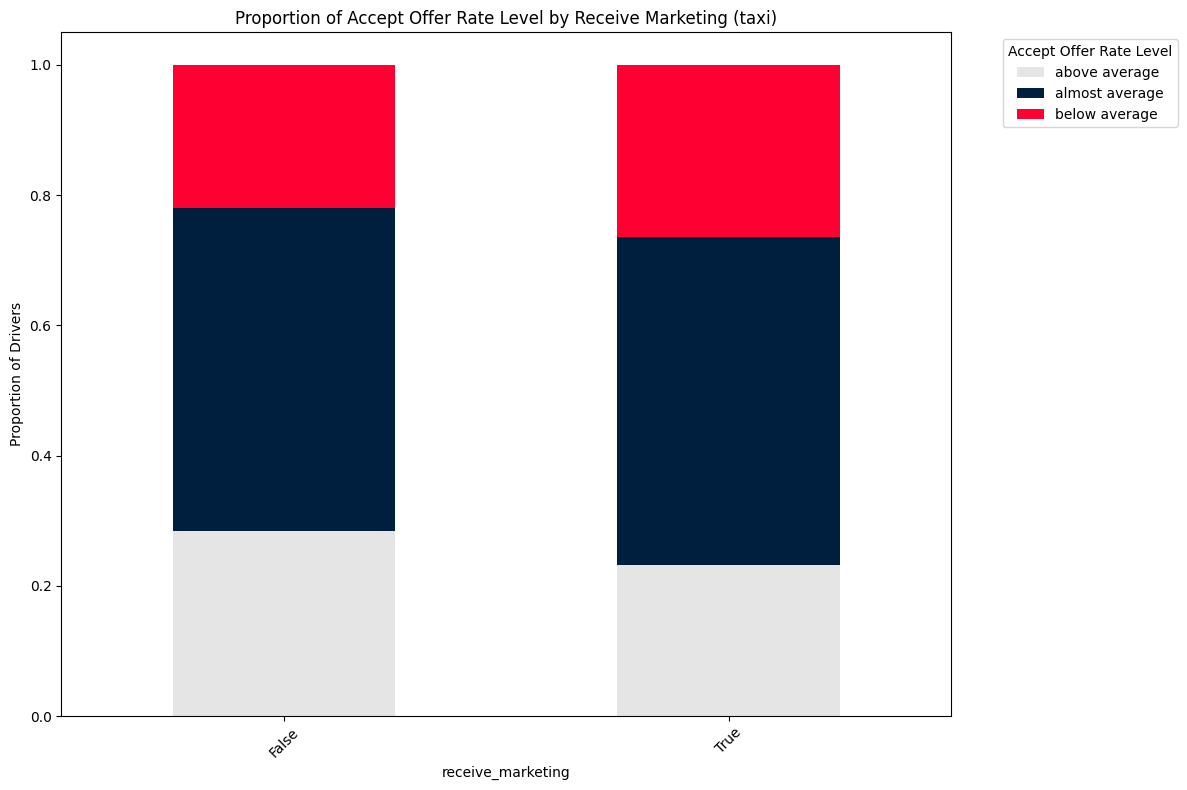

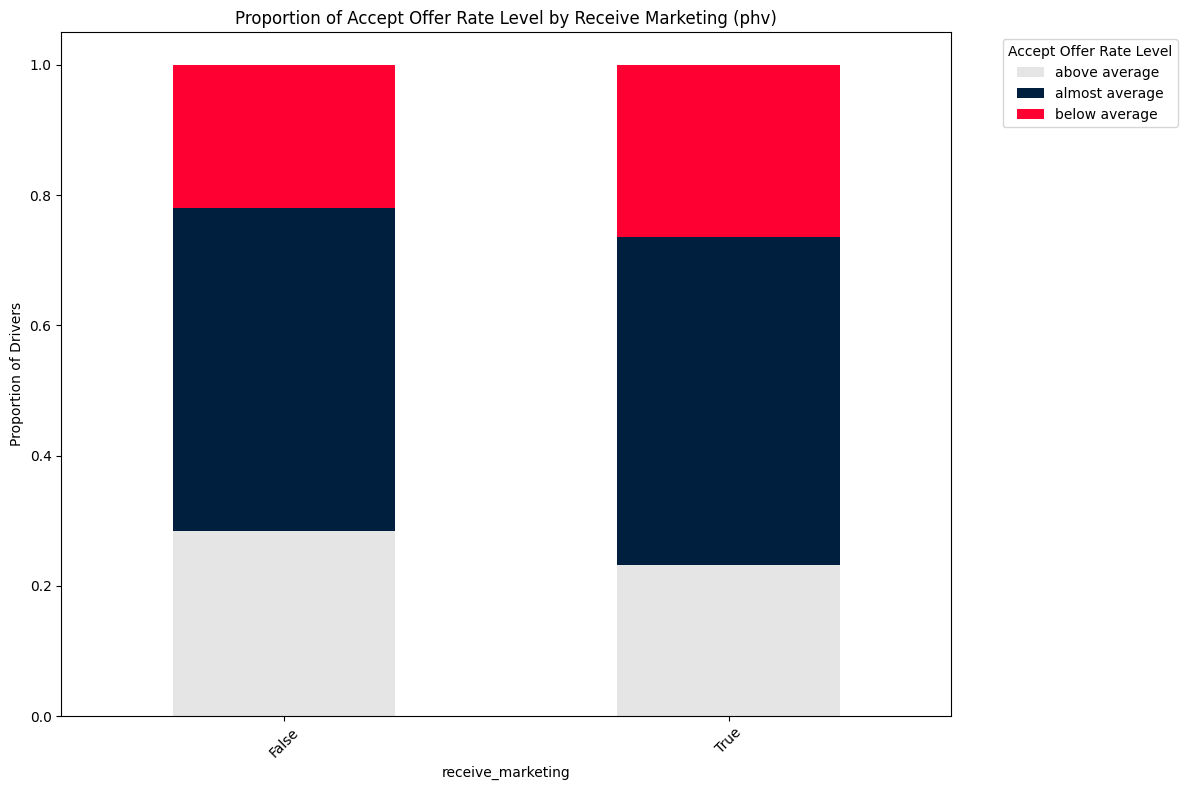

In [87]:
plot_stacked_bar_proportions(final_table_taxi_filtered, 'receive_marketing', 'accept_offer_rate_level')
plot_stacked_bar_proportions(final_table_private_filtered, 'receive_marketing', 'accept_offer_rate_level')

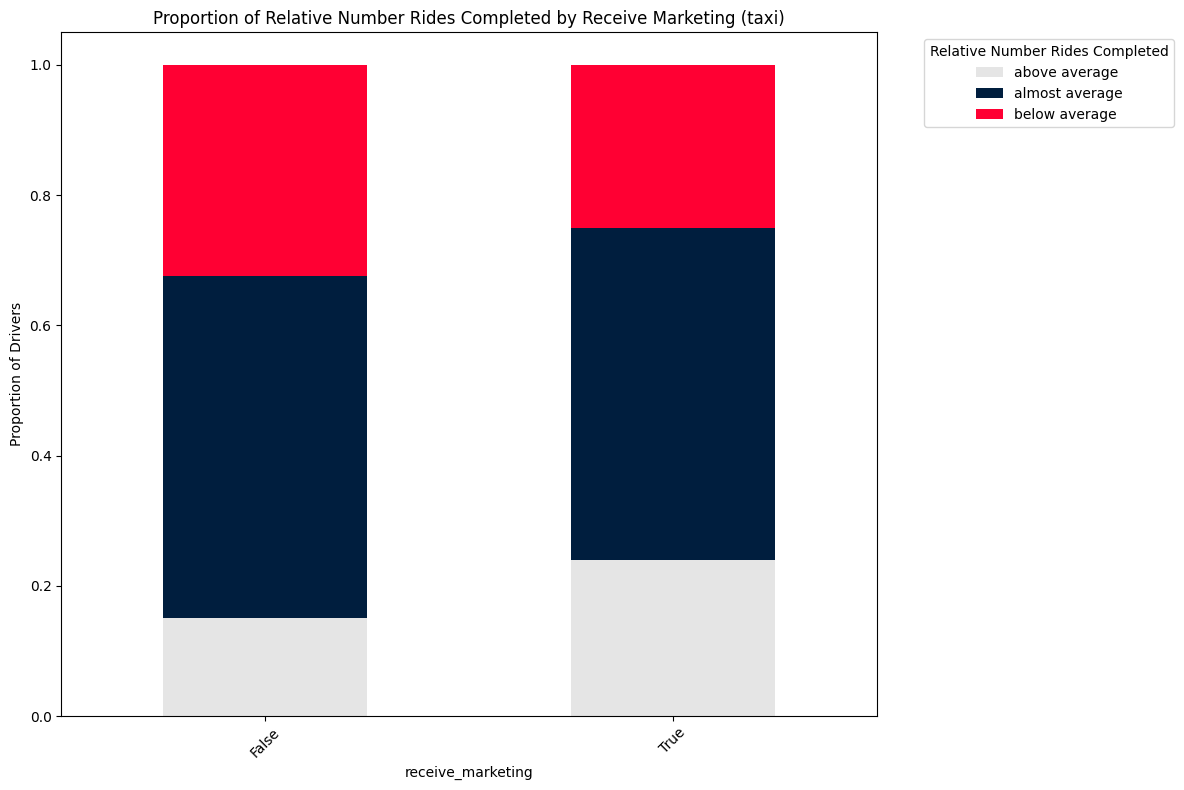

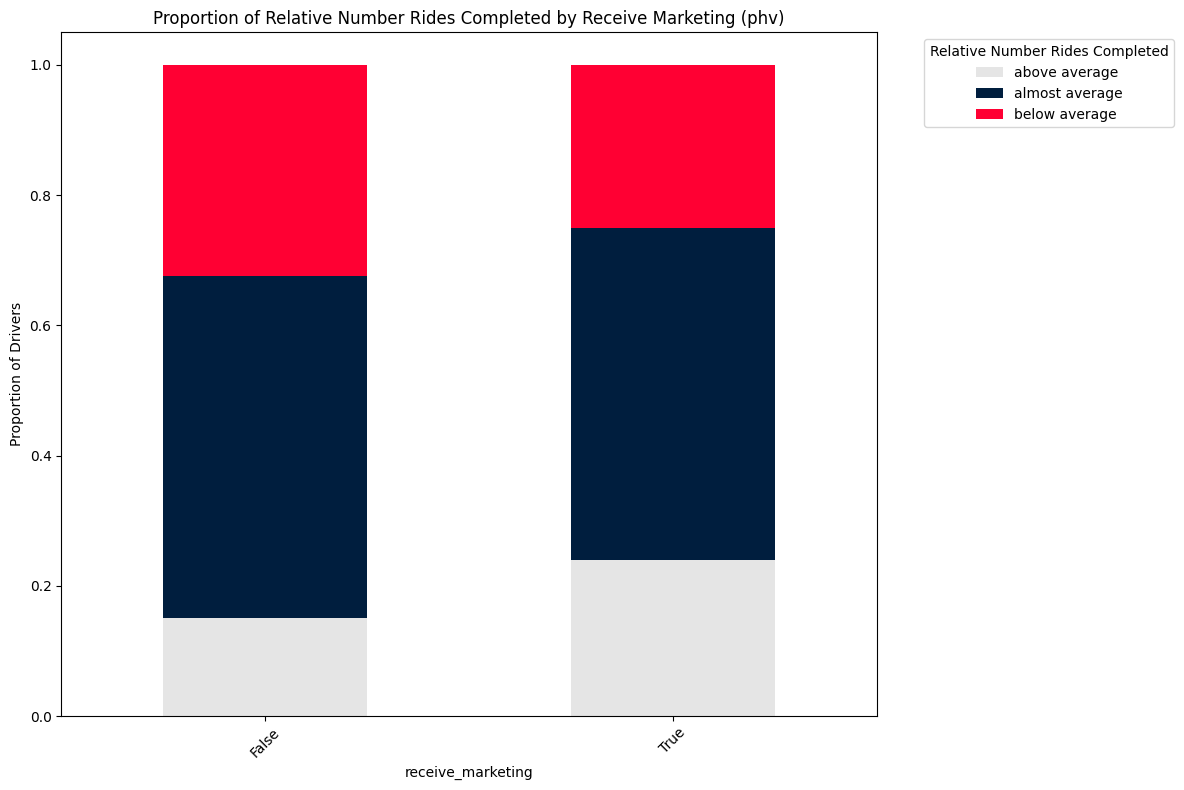

In [88]:
plot_stacked_bar_proportions(final_table_taxi_filtered, 'receive_marketing', 'relative_number_rides_completed')
plot_stacked_bar_proportions(final_table_private_filtered, 'receive_marketing', 'relative_number_rides_completed')

What is interesting here: marketing doesnt really show a great evidence of improving accept rate and conversion. On the other side - these metrics show worse perfomance to the group with no marketing except the overall number of rides completed. 

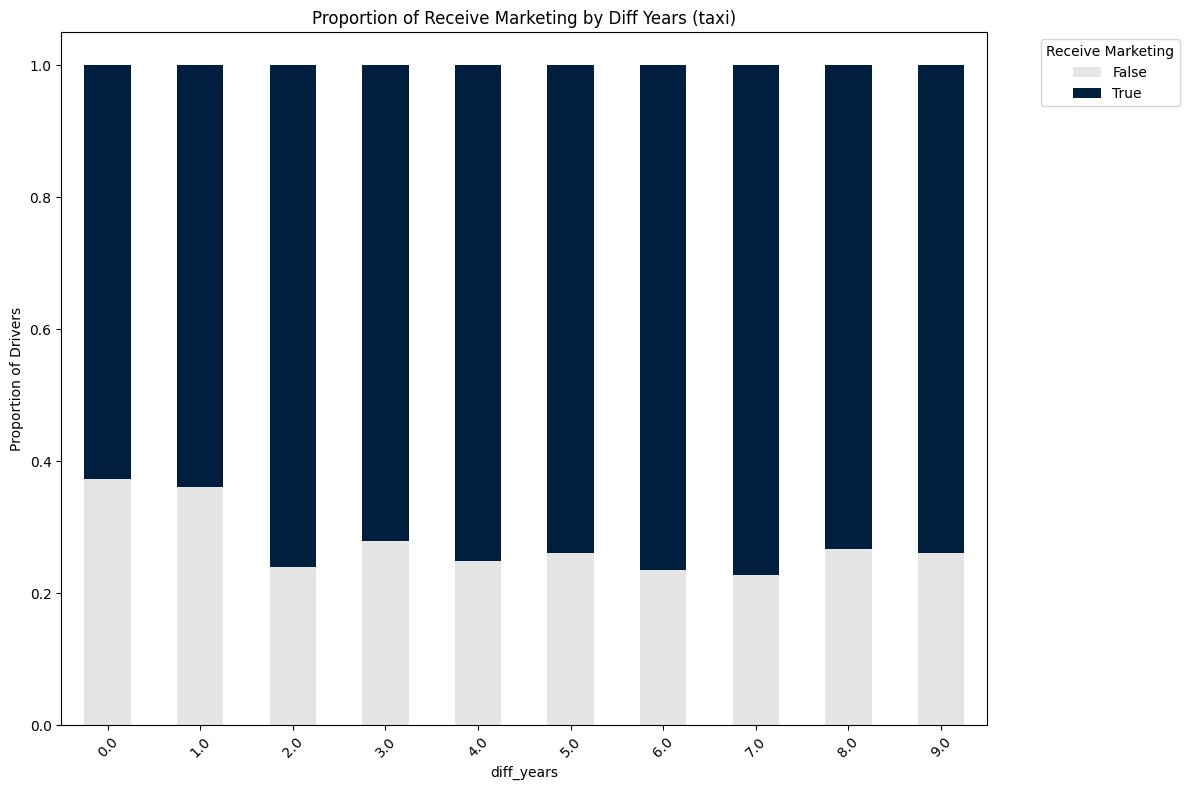

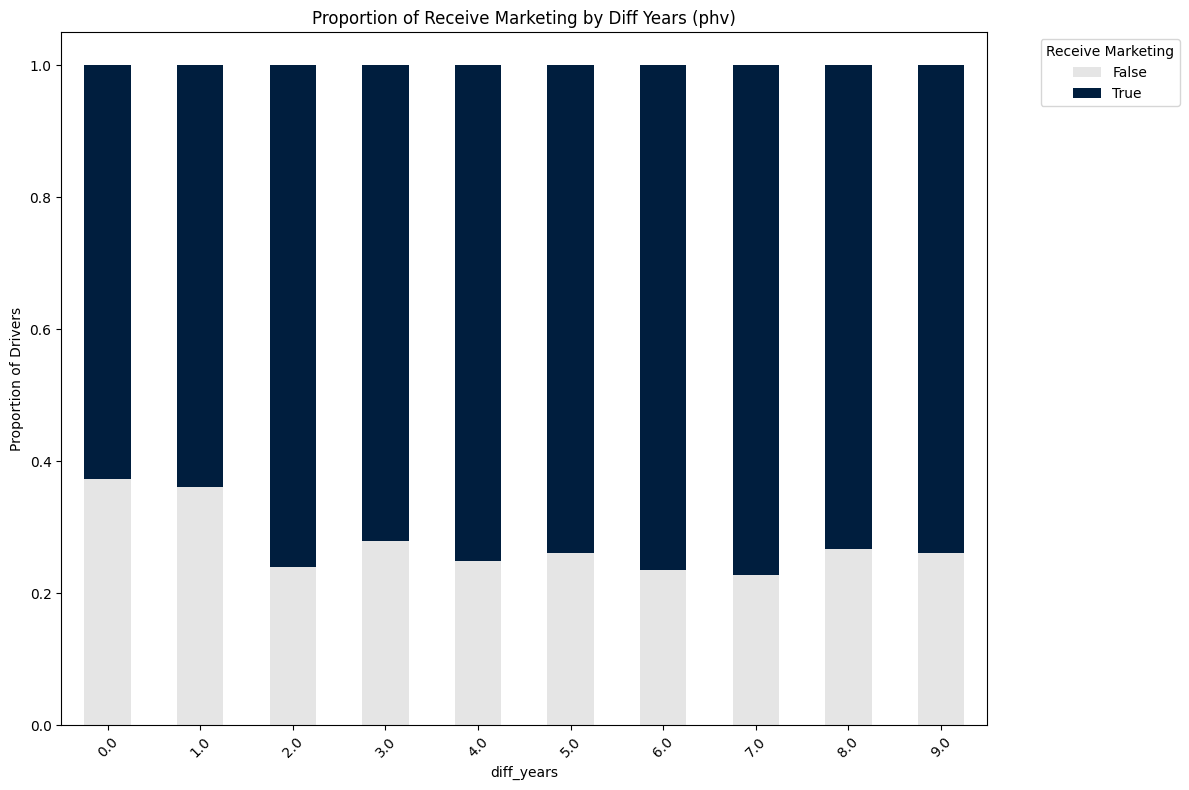

In [89]:
plot_stacked_bar_proportions(final_table_taxi_filtered, 'diff_years', 'receive_marketing')
plot_stacked_bar_proportions(final_table_private_filtered, 'diff_years', 'receive_marketing')

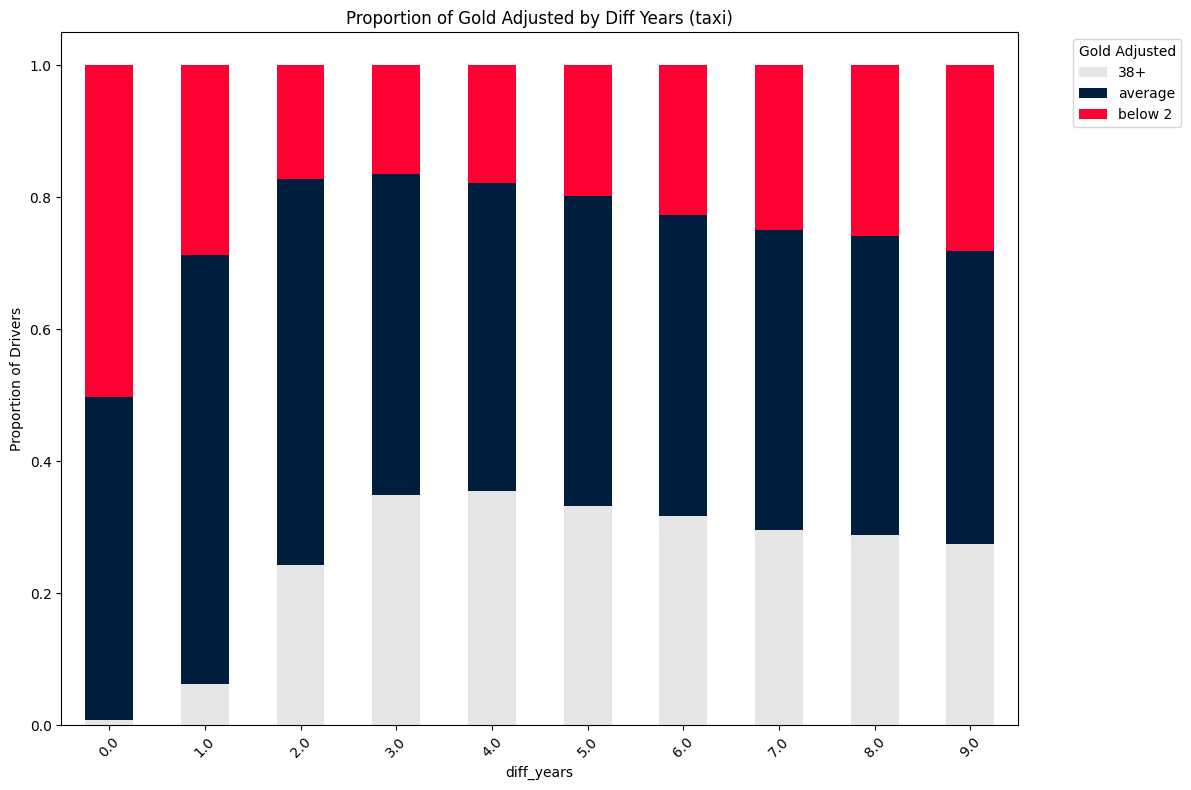

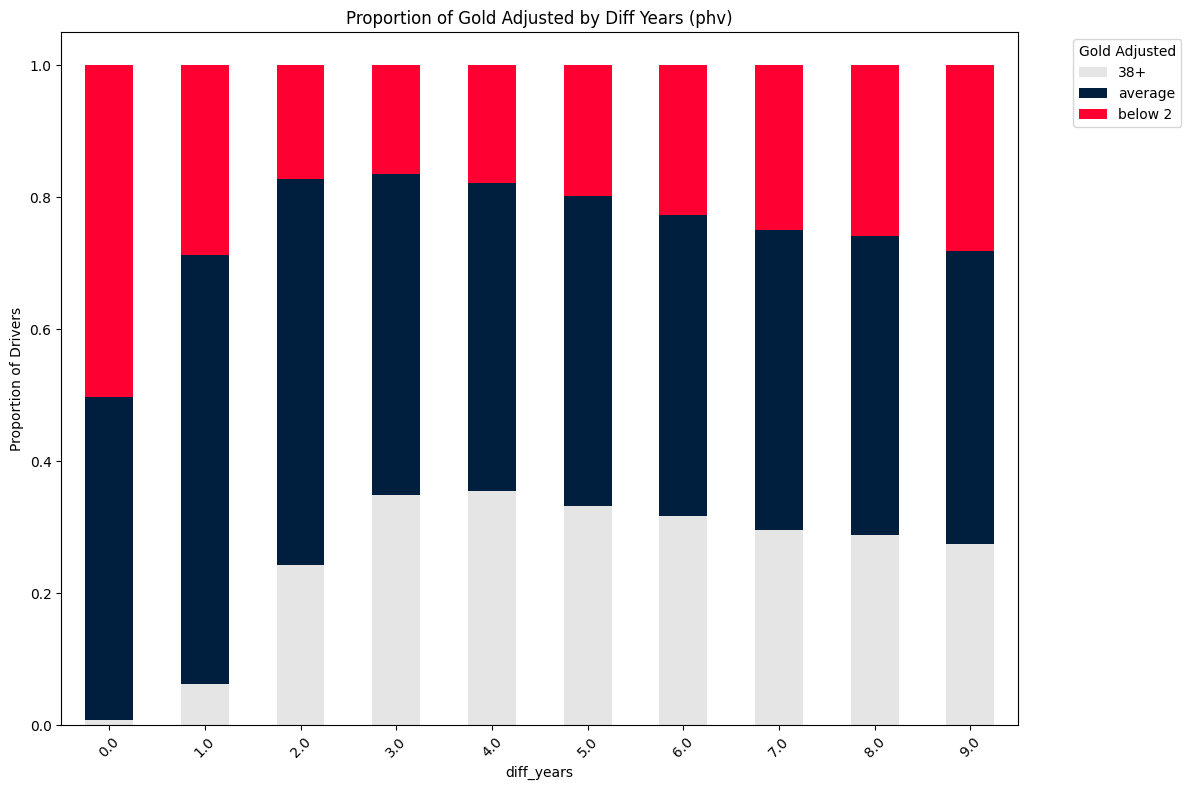

In [90]:
plot_stacked_bar_proportions(final_table_taxi_filtered, 'diff_years', 'gold_adjusted')
plot_stacked_bar_proportions(final_table_private_filtered, 'diff_years', 'gold_adjusted')

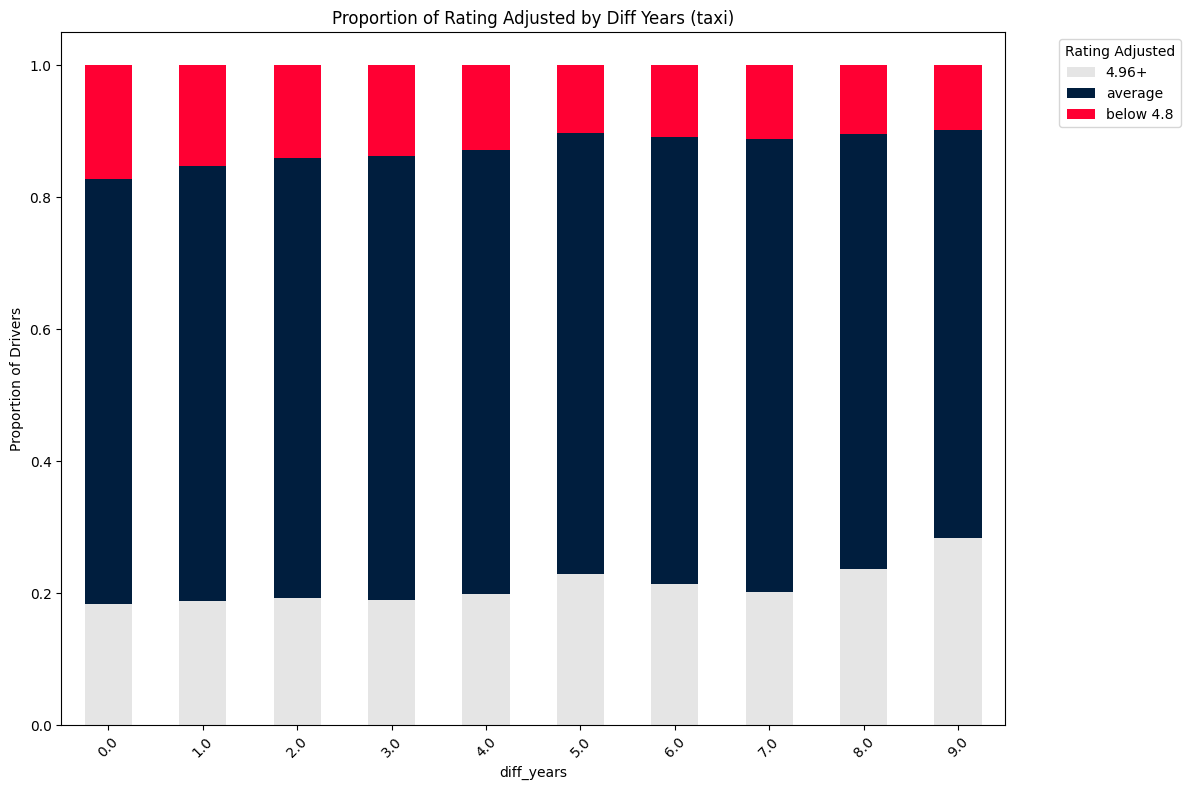

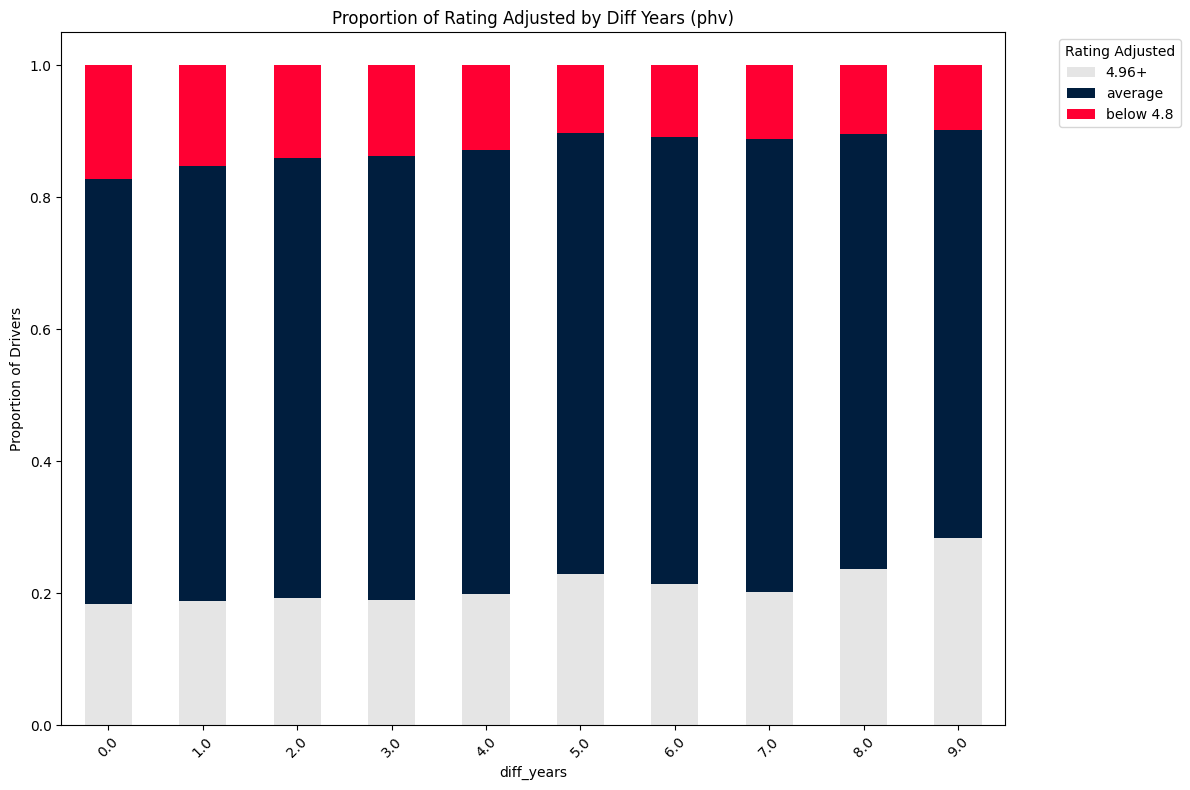

In [91]:
plot_stacked_bar_proportions(final_table_taxi_filtered, 'diff_years', 'rating_adjusted')
plot_stacked_bar_proportions(final_table_private_filtered, 'diff_years', 'rating_adjusted')

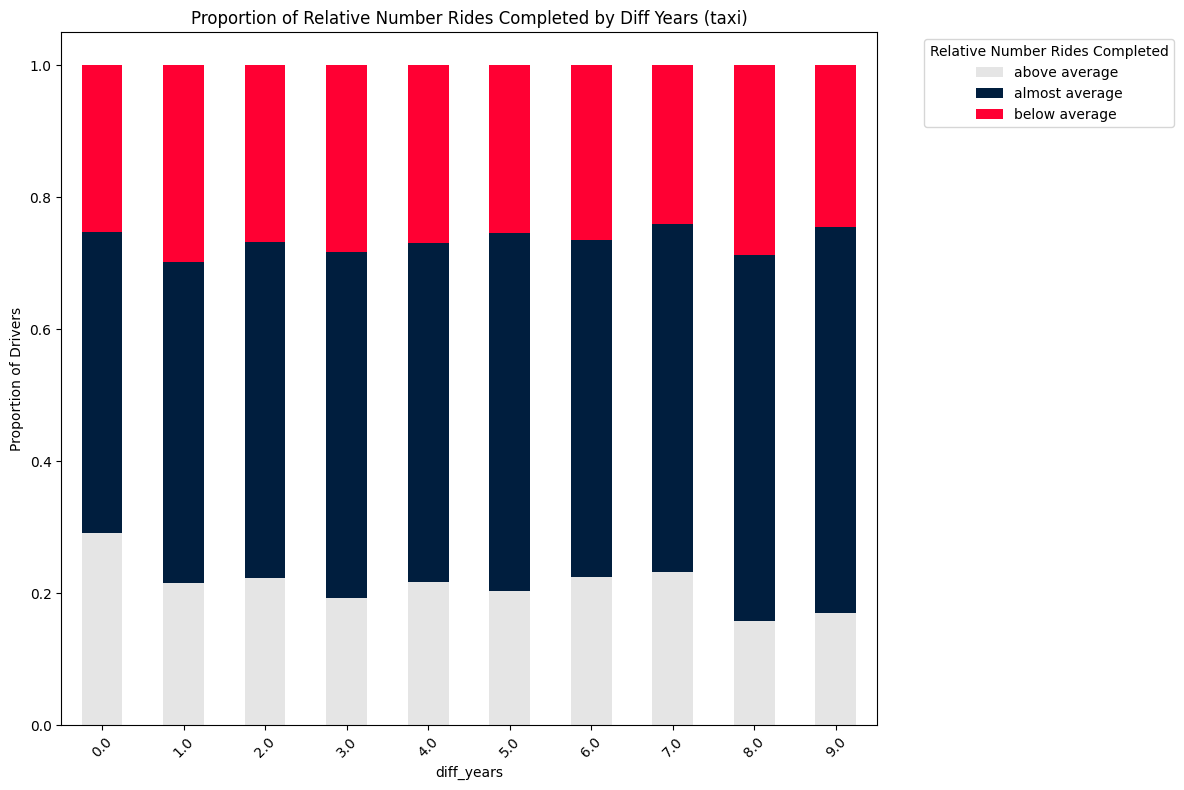

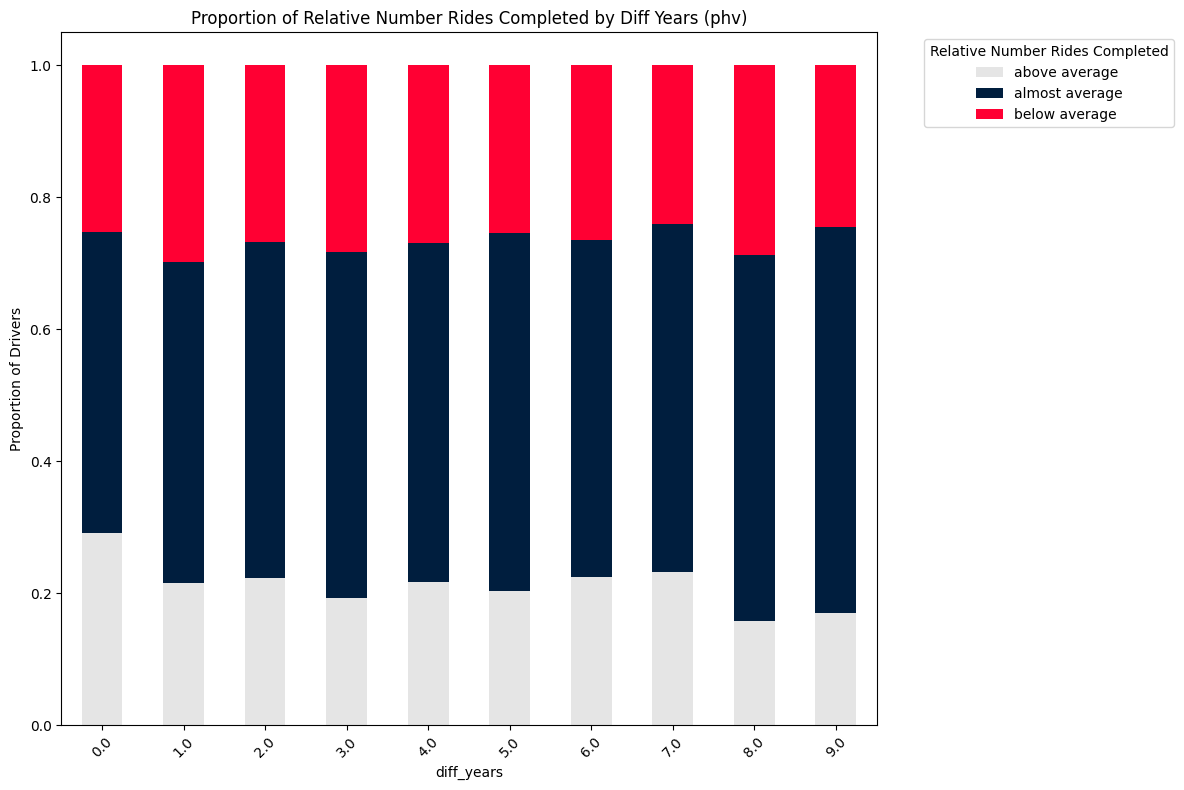

In [92]:
plot_stacked_bar_proportions(final_table_taxi_filtered, 'diff_years', 'relative_number_rides_completed')
plot_stacked_bar_proportions(final_table_private_filtered, 'diff_years', 'relative_number_rides_completed')

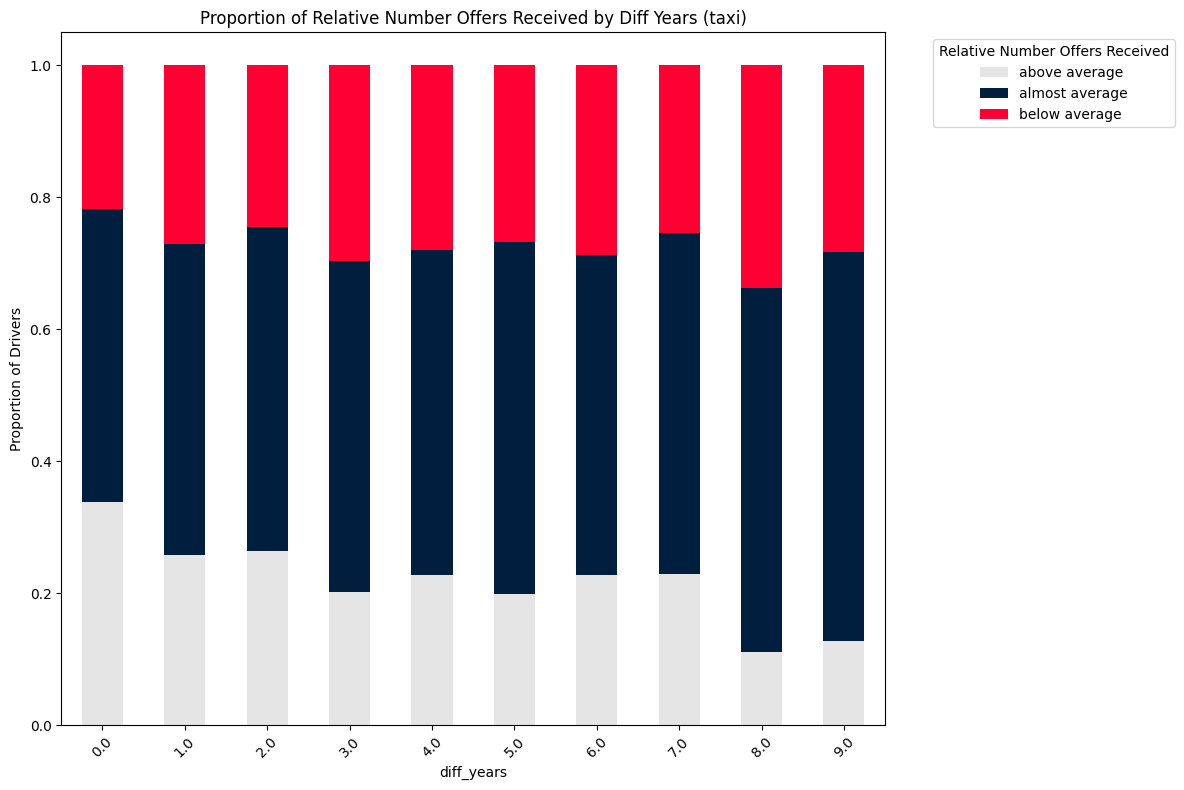

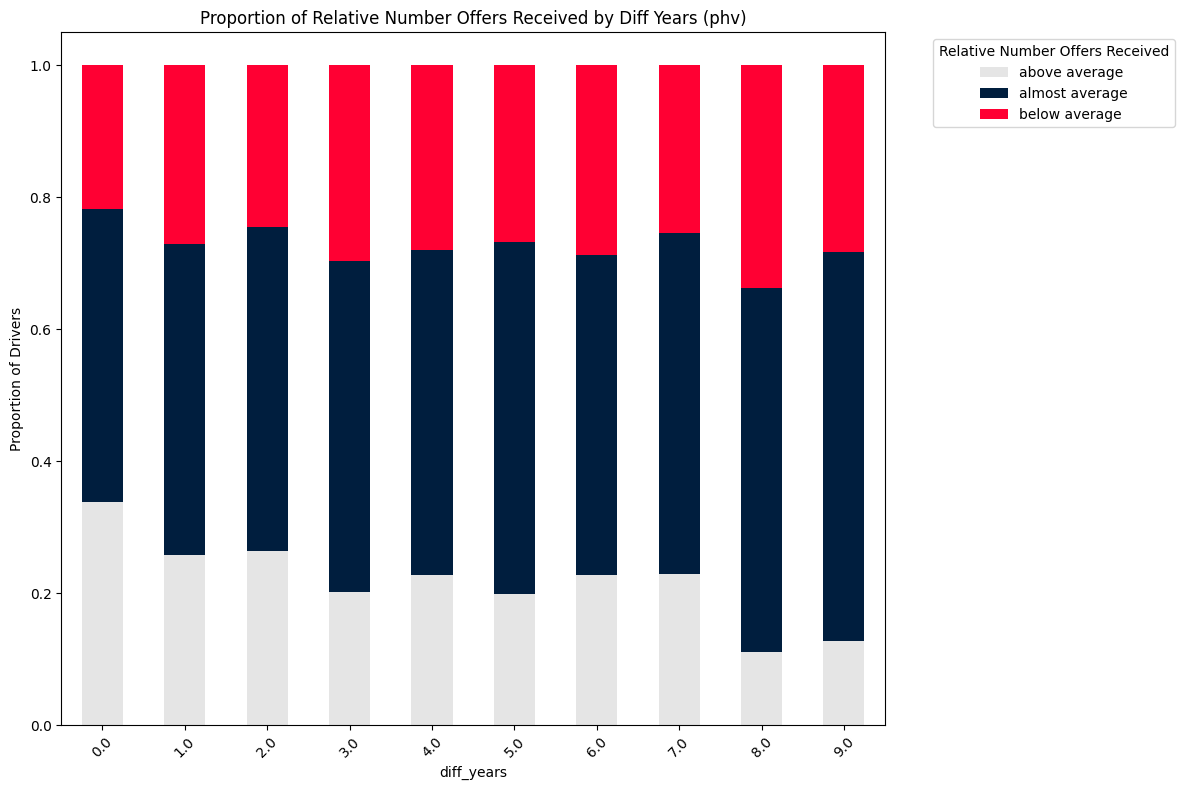

In [93]:
plot_stacked_bar_proportions(final_table_taxi_filtered, 'diff_years', 'relative_number_offers_received')
plot_stacked_bar_proportions(final_table_private_filtered, 'diff_years', 'relative_number_offers_received')

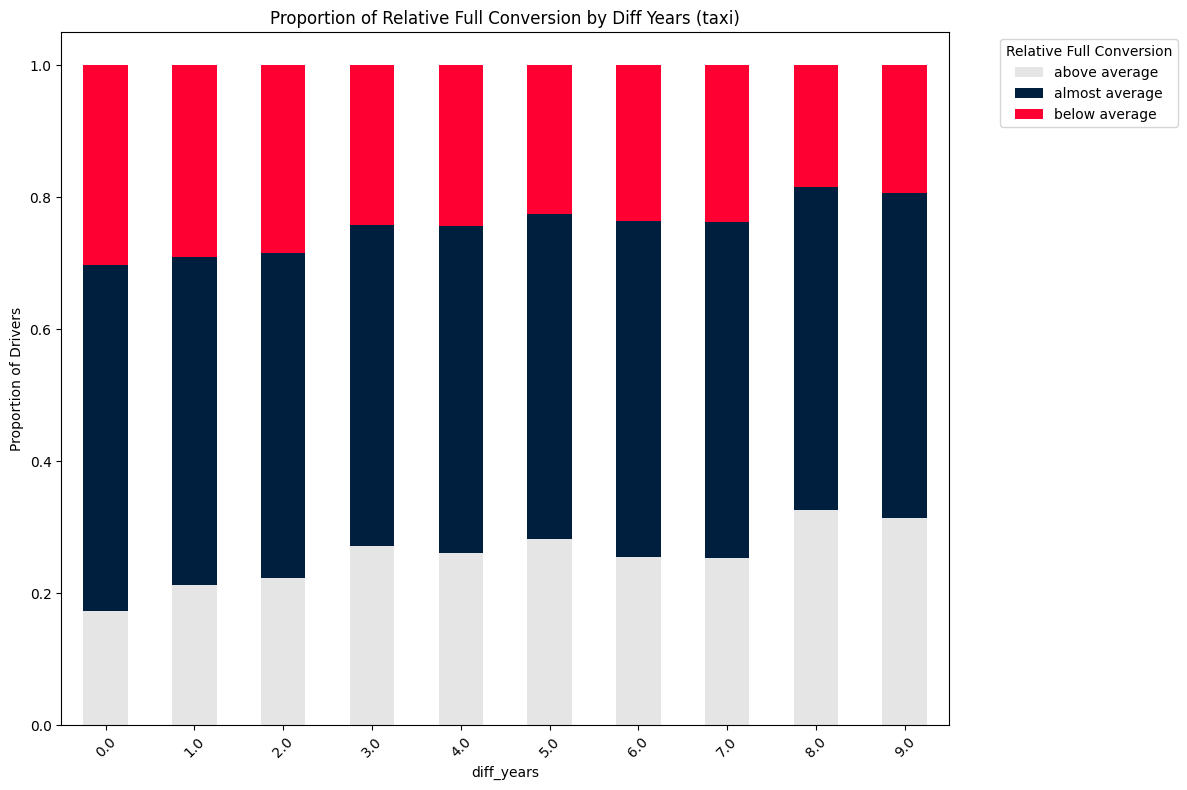

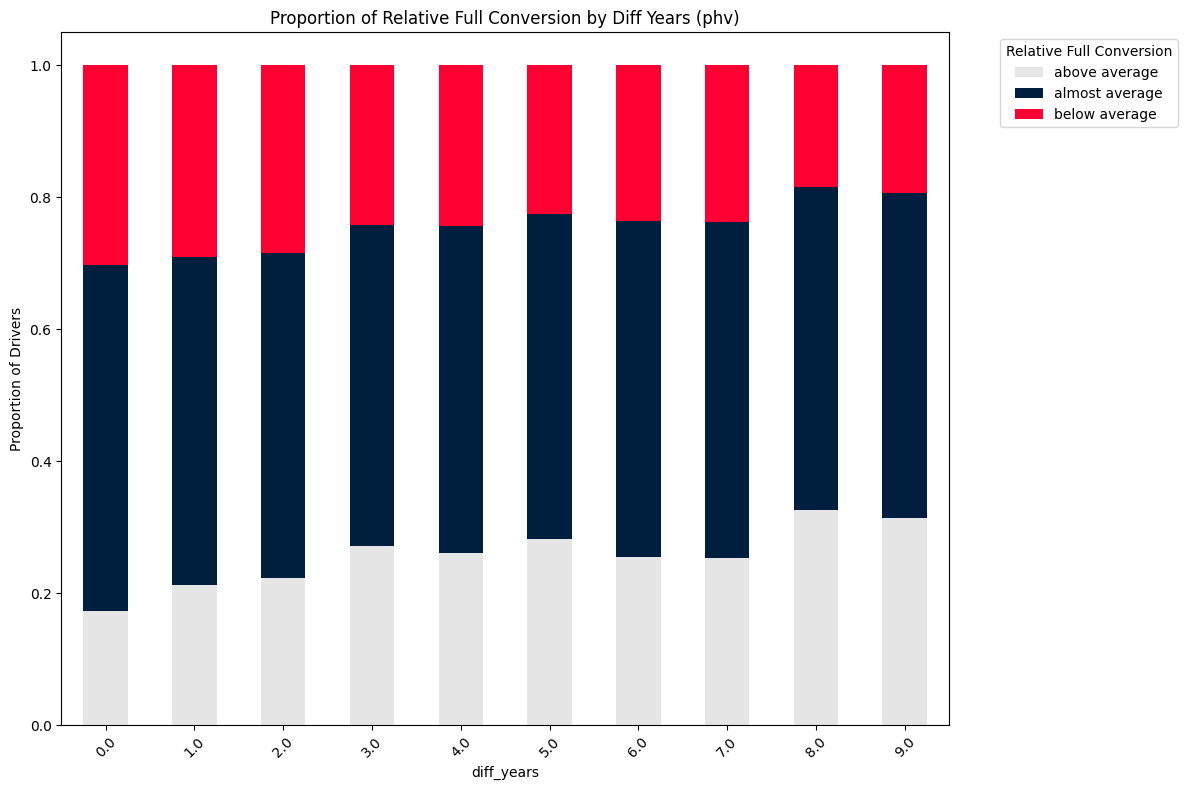

In [94]:
plot_stacked_bar_proportions(final_table_taxi_filtered, 'diff_years', 'relative_full_conversion')
plot_stacked_bar_proportions(final_table_private_filtered, 'diff_years', 'relative_full_conversion')

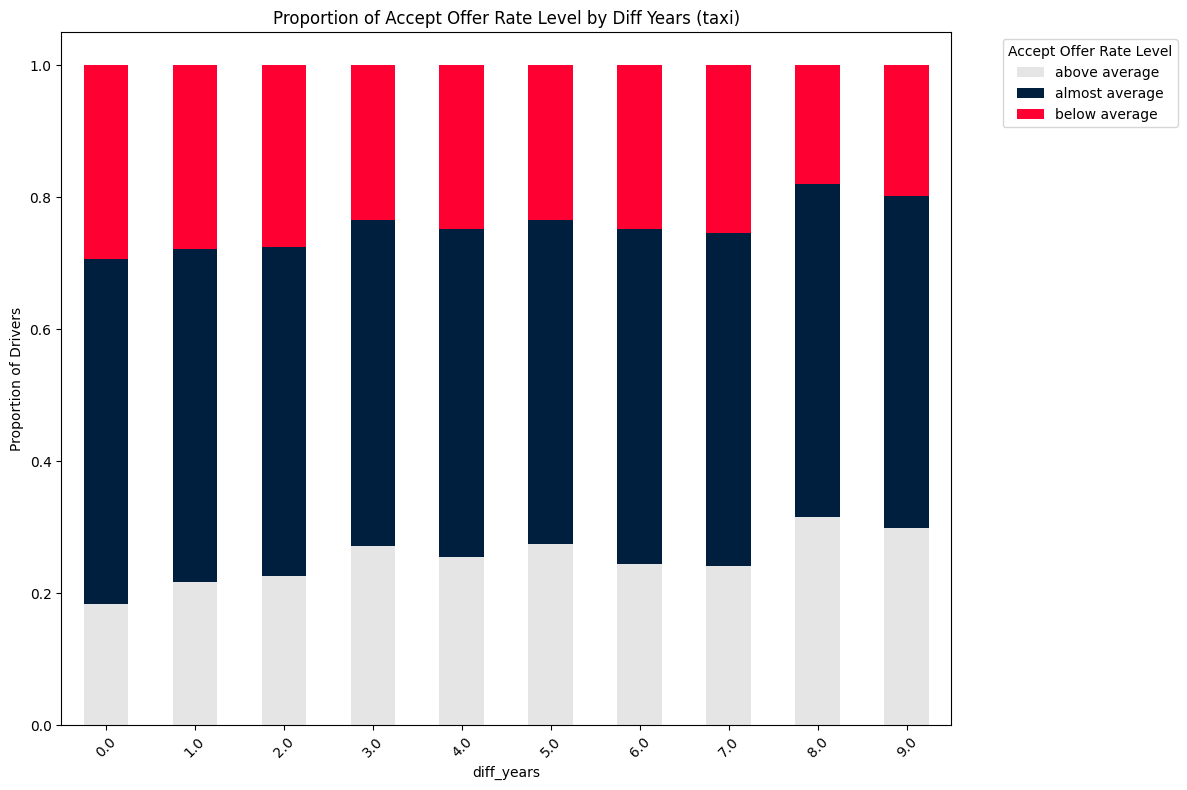

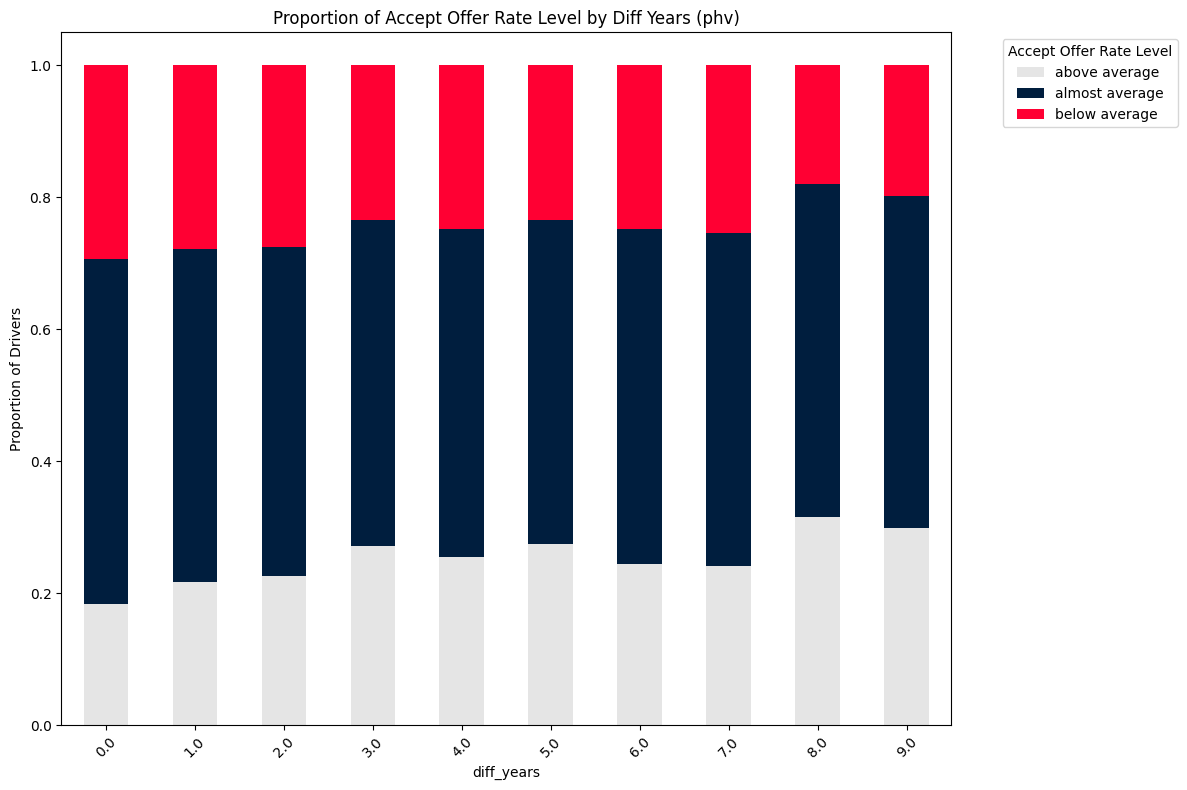

In [95]:
plot_stacked_bar_proportions(final_table_taxi_filtered, 'diff_years', 'accept_offer_rate_level')
plot_stacked_bar_proportions(final_table_private_filtered, 'diff_years', 'accept_offer_rate_level')

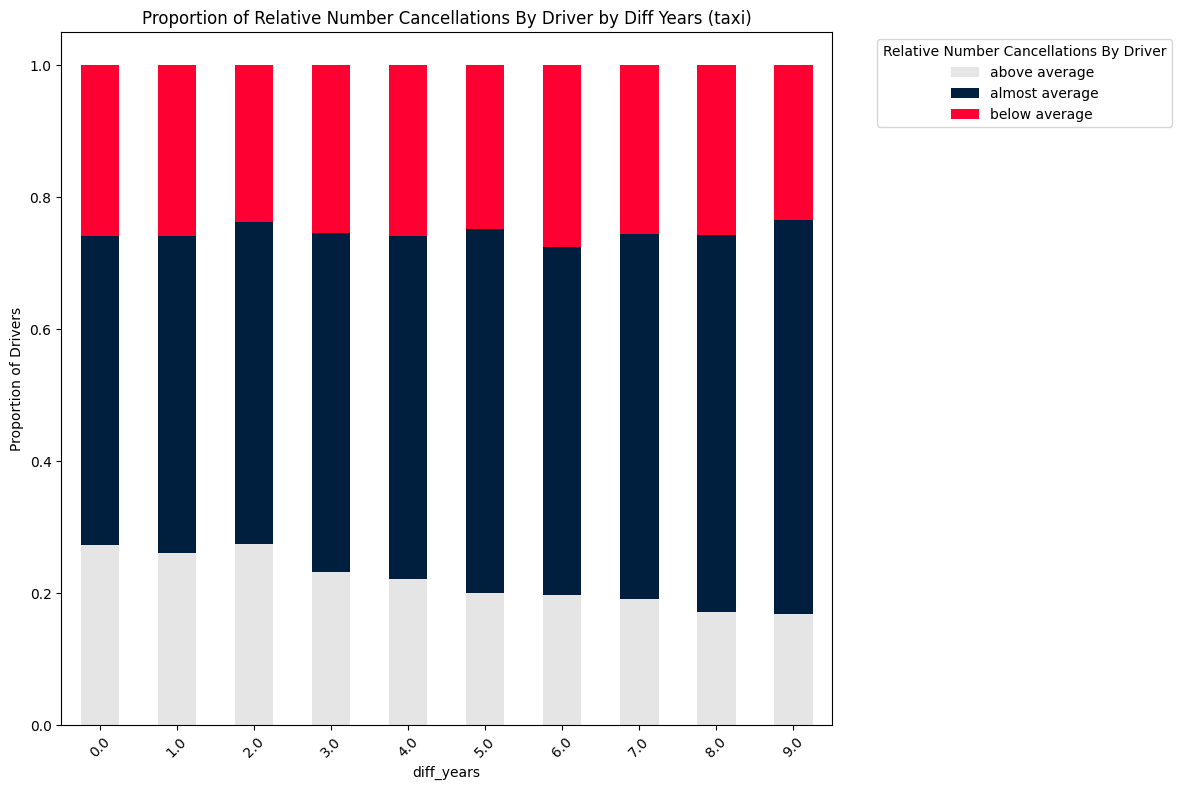

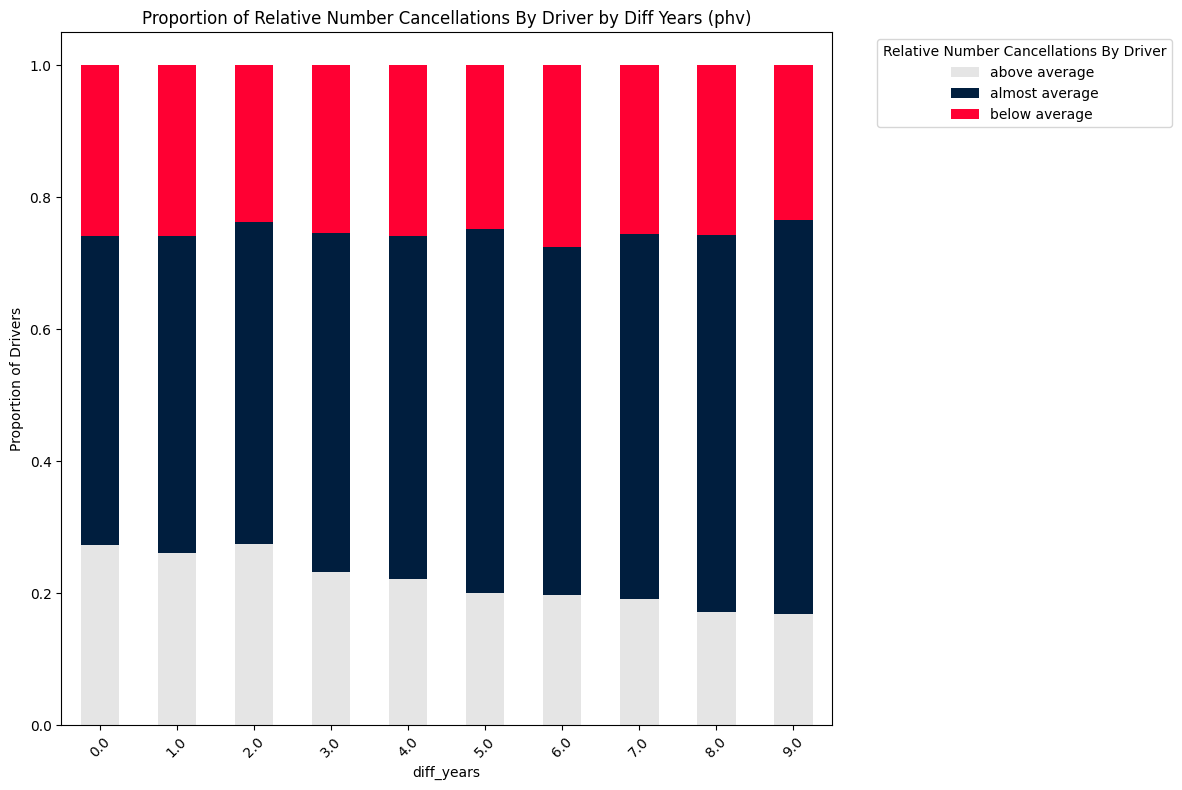

In [96]:
plot_stacked_bar_proportions(final_table_taxi_filtered, 'diff_years', 'relative_number_cancellations_by_driver')
plot_stacked_bar_proportions(final_table_private_filtered, 'diff_years', 'relative_number_cancellations_by_driver')

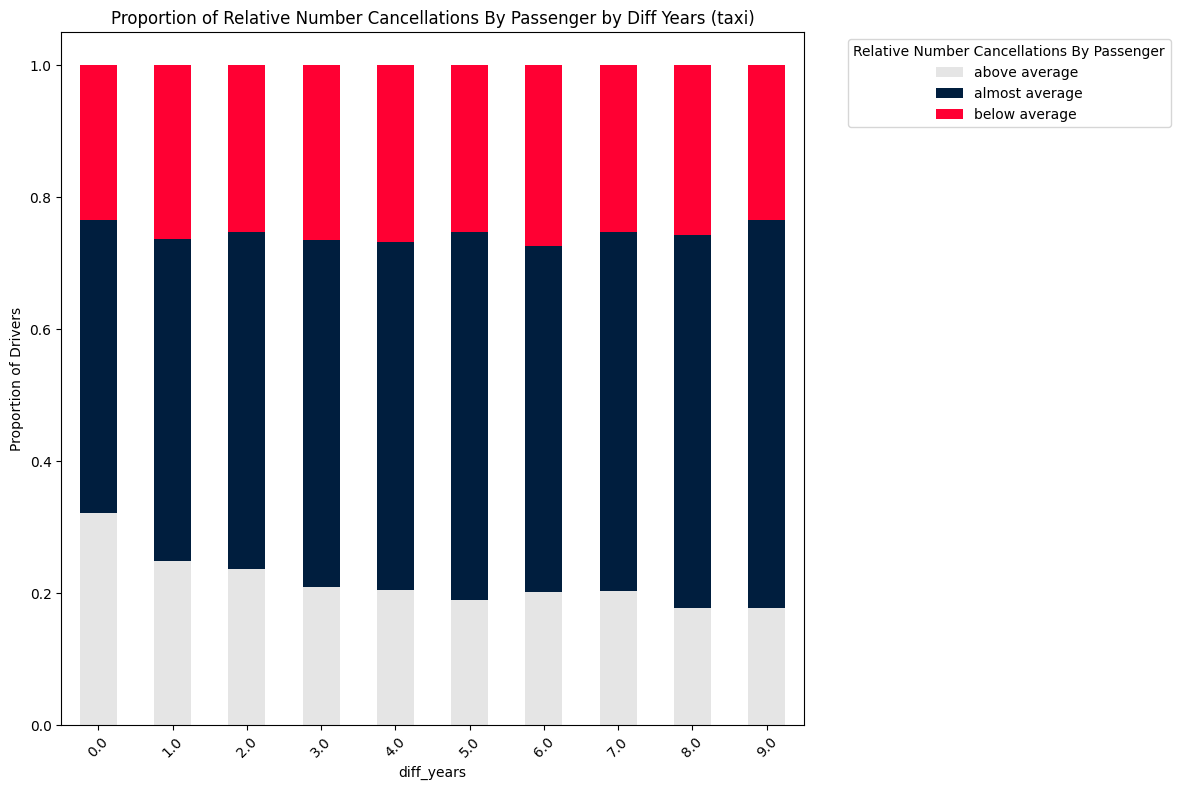

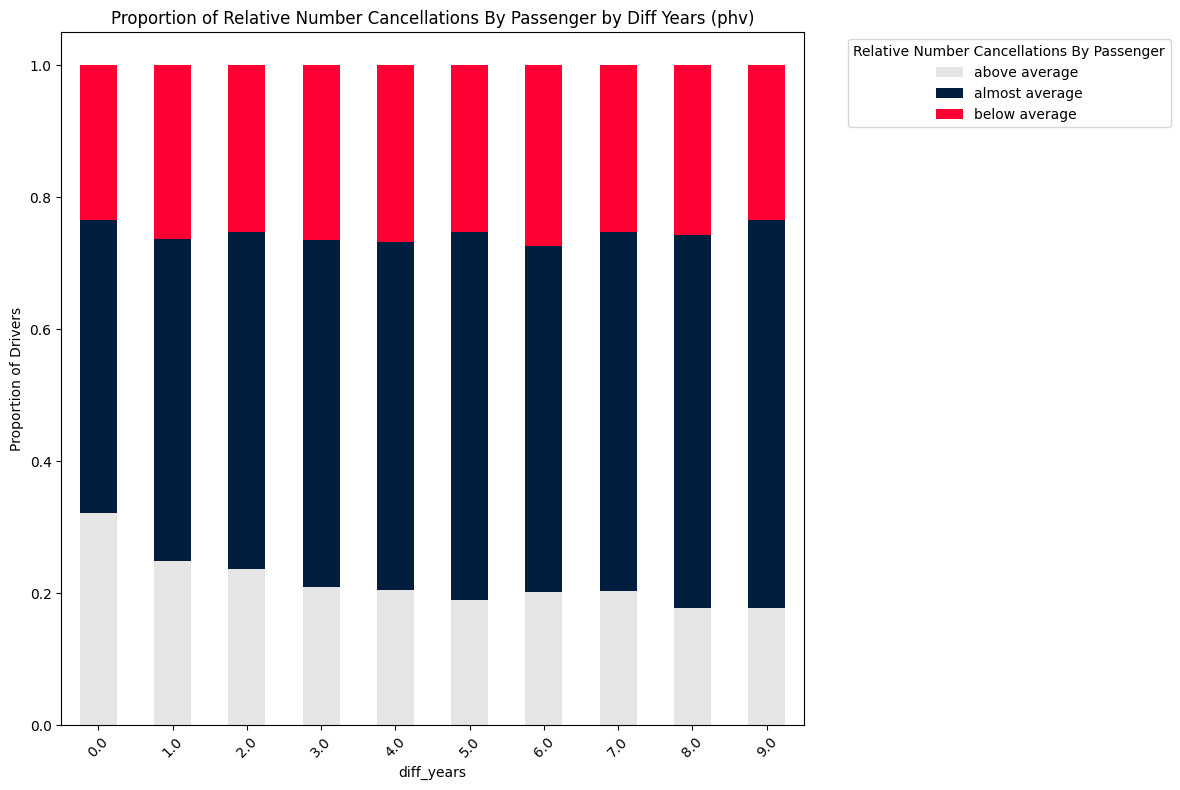

In [97]:
plot_stacked_bar_proportions(final_table_taxi_filtered, 'diff_years', 'relative_number_cancellations_by_passenger')
plot_stacked_bar_proportions(final_table_private_filtered, 'diff_years', 'relative_number_cancellations_by_passenger')

for both private and regular taxi pictures are the same: more offers and more rides for those drivers who are relatively new to the system, but conversion and accept offer really strugle with them. Also number of cancelations from both sides is increased in the group of new riders. 

## Conclusion 

### 📊 Data Processing

#### 1. Removal of Invalid Records
- ~2% of records from the *Activity Log* were removed due to unsuitability.
- Spain was not presented in private hire. Because of over complication i decided to eliminate this level of analysis. 

#### 2. Driver Data Handling
- The driver table was **split into two parts** to address **duplicate entries**.
- Some drivers appeared in both **Private Hire** and **Regular Taxi** services, requiring separation to avoid bias.

---

### 🎯 Goal of the Analysis

To determine **which mechanisms or strategies increase driver engagement** with the platform.

---

### 🧩 Key Engagement Drivers Identified

#### 1. Driver Rating
- Formed externally through **rider feedback** (outside of company control).
- Strongly **correlated with engagement**:
  - Higher ratings → more accepted offers.
  - Higher ratings → fewer cancellations.

#### 2. Performance Awards *(e.g., Gold Awards, Top Performer badges)*
- Given for **high monthly trip volume**.
- Positively associated with:
  - **Higher offer-to-trip conversion**.
  - **Lower cancellation rates**.
  - **Mostly given to drivers with 3+ years of experince**

#### 3. Marketing Campaigns
- Aim to boost driver activity. New drivers receive campaign more frequntly
- Outcomes:
  - **Increase in total trips** completed.
  - However, **lower conversion and offer acceptance rates**.
    - Reason unclear; may relate to oversaturation, targeting, or behavioral effects.

---

### 👥 Driver Characteristics & Impact

#### 1. Tenure (Time on Platform)
- **New drivers (< 1 year):**
  - Receive the **most offers**.
  - But show:
    - **Lower conversion rates**.
    - **Higher cancellation rates** (both driver- and rider-initiated).

- **Experienced drivers:**
  - More likely to:
    - Accept offers.
    - Complete rides.
    - Have high ratings and earn awards.

---

### ✅ Key Insights

- **Ratings** and **awards** are effective **indirect levers** to boost engagement.
  - Positively correlated with offer acceptance and trip completion.
  - Negatively correlated with cancellations.

- **Marketing campaigns** increase total rides but **reduce engagement quality** (conversion & acceptance).
  - Indicates potential **misalignment in execution or targeting**.

- **New drivers** require **additional support**:
  - Lower performance.
  - Higher churn risk.
  - Strong case for onboarding or mentorship programs.

---

### 🔧 Strategic Recommendations

- Strengthen **recognition and reward programs**.
- Increase **transparency and influence of driver ratings**.
- **Refine marketing campaign targeting** and rollout.
- Introduce **onboarding/mentorship initiatives** for new drivers.



# A/B Test 

Using the data from Freenow_drivers_campaign file, please answer:
On a separate initiative, the team wanted to find out if a certain email campaign works to
incentivise the drivers to be more active in our platform.To do so we divided the drivers in
two groups A and B. Group B received an email informing drivers of when we expect high
customer demand in the following week. Group A did not receive the email. Please find
out about the effect of the campaign. Explain how you determine the impact and why you
chose such a method to evaluate it.

In [98]:
Freenow_drivers_campaign.head()

,driver,rides_within_week,test_group
0,1,88,A
1,2,56,B
2,3,80,B
3,4,49,A
4,5,61,A


First lets start with overall statistics

In [99]:
grouped_data = Freenow_drivers_campaign.groupby('test_group').agg({'driver': 'count', 'rides_within_week': 'sum'}).reset_index()

In [100]:
grouped_data = grouped_data.rename(columns = {'driver': 'group_size', 'rides_within_week': 'total_rides'})

In [101]:
grouped_data['rides_per_driver'] = grouped_data['total_rides'] / grouped_data['group_size']

In [102]:
grouped_data

,test_group,group_size,total_rides,rides_per_driver
0,A,5000,250225,50.0450
1,B,5000,260584,52.1168


Distribution is 50/50 which is good. Other settings for the test are unavailable for me, so i cannot tell, wether it was set up correctly 

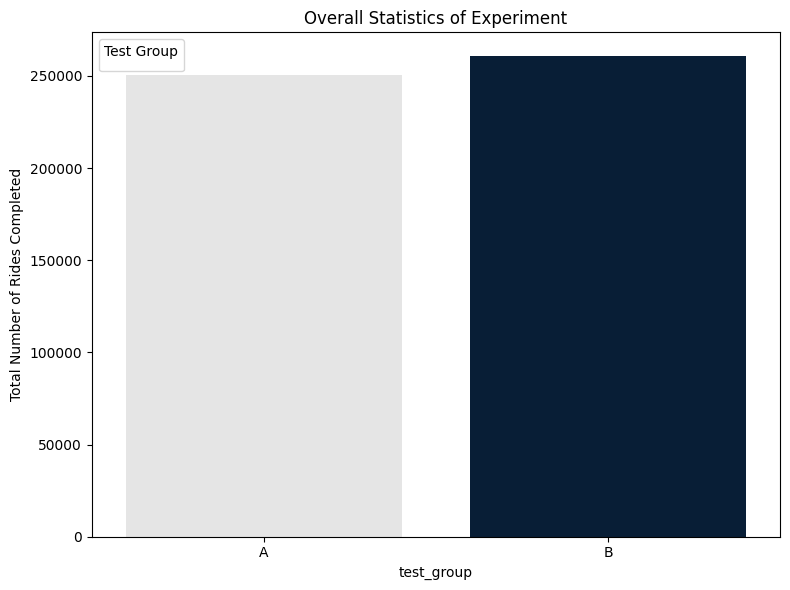

In [103]:
group_colors = {
    'A': '#E5E5E5',  # Light Grey
    'B': '#001E3E'   # Dark Blue
}

plt.figure(figsize=(8,6))
sns.barplot(
    x='test_group',
    y='total_rides',
    hue='test_group',
    data=grouped_data,
    palette=group_colors
)
plt.title('Overall Statistics of Experiment')
plt.ylabel('Total Number of Rides Completed')
plt.legend(title='Test Group')
plt.tight_layout()
plt.show()

Ok, that is clear that one group completed more rides than the other. The task is to check, whether it is likely due to random reasons and most likely there is no actual difference or it really exists 

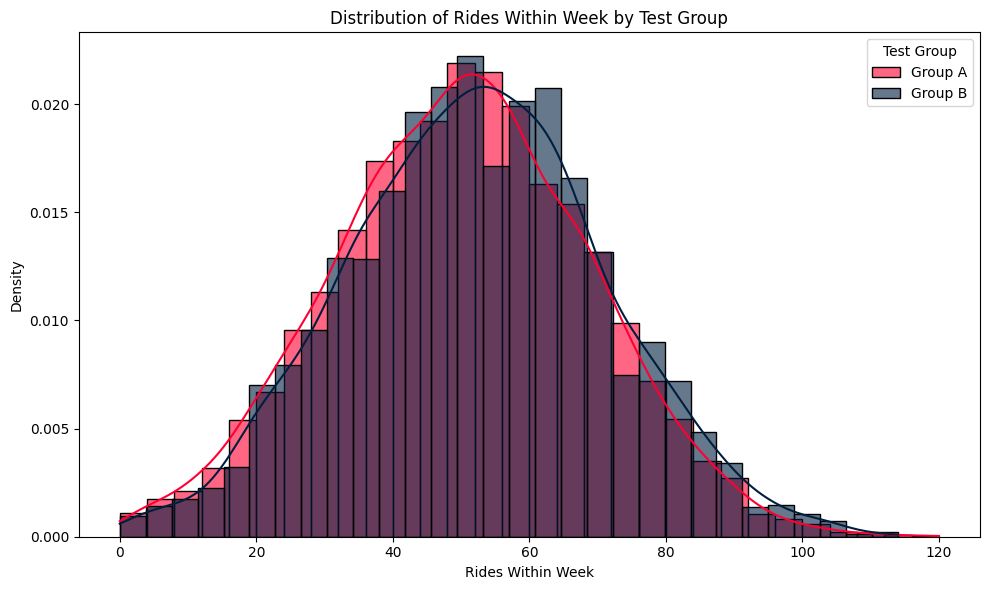

In [104]:
freenow_colors = {
    'A': '#FF0033',   # Red
    'B': '#001E3E',   # Blue
}

plt.figure(figsize=(10, 6))

for group in ['A', 'B']:
    sns.histplot(
        data=Freenow_drivers_campaign[Freenow_drivers_campaign['test_group'] == group],
        x='rides_within_week',
        kde=True,
        stat="density",
        label=f'Group {group}',
        color=freenow_colors[group],
        alpha=0.6,
        bins=30
    )

plt.title("Distribution of Rides Within Week by Test Group")
plt.xlabel("Rides Within Week")
plt.ylabel("Density")
plt.legend(title="Test Group")
plt.tight_layout()
plt.show()

Distribution looks normal, lets check it properly 

In [105]:
from scipy.stats import kstest

for group in ['A', 'B']:
    data = Freenow_drivers_campaign[Freenow_drivers_campaign['test_group'] == group]['rides_within_week']
    stat, p = kstest(data, 'norm', args=(data.mean(), data.std()))
    print(f"Group {group} - K-S test p-value: {p:.5f}")

Group A - K-S test p-value: 0.11945
Group B - K-S test p-value: 0.15578


The data in both groups A and B are not significantly different from a normal distribution — it's reasonable to assume they are approximately normally distributed. thus i am going to use a Two-Sample Independent T-Test.

Here's why:

No informations about STD in the populations. So I use approximations of t test for it. 

Two Independent Groups: we have distinct groups (A and B) that are not related to each other.

Normal Distribution: The t-test is robust to deviations from normality with large sample sizes, but knowing the distribution is normal makes it even more suitable.

Large Sample Sizes: With N=5000 for each group, the t-distribution will closely approximate the normal distribution.

Comparing Means: The goal is to compare the 'total_rides' (which, when normalized by group size, gives the mean rides per driver or per a specific unit within the group) between the two groups. A t-test is designed to compare means.

In [106]:
from scipy.stats import ttest_ind

group_a = Freenow_drivers_campaign[Freenow_drivers_campaign['test_group'] == 'A']['rides_within_week']
group_b = Freenow_drivers_campaign[Freenow_drivers_campaign['test_group'] == 'B']['rides_within_week']

t_stat, p_value = ttest_ind(group_a, group_b, equal_var=True)
print(f"Two-sample t-test p-value: {p_value:.5f}")


Two-sample t-test p-value: 0.00000


P-value is lower then 0.05 and thus we can conclude that the difference between 2 groups is statistically significant. Group B has significantly higher means than group A. And this deff is 2.1168 ride per driver within a week. Scipy doesnt allow to conduct directly a ne sided test for higher precision, but p_value is so low (0), so deviding it by 2 wont give anything new. (if positive p/2, engative 1-(p/2))